# Deteccion de Activos Infravalorados: Modelado de Precios con Machine Learning y NLP

El objetivo es desarrollar un sistema que extraiga datos de forma masiva de un portal inmobiliario (pisos.com) y entrene un modelo de regresión enriquecido con variables semánticas extraídas por un LLM. La finalidad última es identificar anomalías de mercado: listados donde el Precio Real es significativamente inferior al Precio Predicho por el sistema.

## Web Scrapping

Extracción de las urls de todos los pisos de Madrid.

In [ ]:
# Imports necesarios para el apartado de Web Scrapping
import requests
from bs4 import BeautifulSoup
import json
import re
import time
import pandas as pd
import os

In [ ]:
def extraer_enlaces_por_distritos(lista_distritos):
    todos_los_enlaces = set() # set para evitar duplicados
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    for distrito in lista_distritos:
        pagina = 1
        print(f"\n--- Iniciando búsqueda en: {distrito} ---")

        while True:
            # Construccion de la URL segun formato
            if pagina == 1:
                url = f"https://www.pisos.com/venta/pisos-{distrito}/"
            else:
                url = f"https://www.pisos.com/venta/pisos-{distrito}/{pagina}/"

            try:
                response = requests.get(url, headers=headers)

                # Si una pagina no existe o error
                if response.status_code != 200:
                    break

                soup = BeautifulSoup(response.text, 'html.parser')
                cuadro_ppal = soup.find("div", class_="grid__wrapper")

                if not cuadro_ppal:
                    break

                anuncios = cuadro_ppal.find_all("div", class_="ad-preview")

                # Si no hay anuncios
                if not anuncios:
                    break

                enlaces_encontrados_en_pagina = 0
                for anuncio in anuncios:
                    enlace = anuncio.get('data-lnk-href')
                    if enlace:
                        url_completa = "https://www.pisos.com" + enlace
                        # Si el enlace ya existe en nuestro set, significa que la web nos ha devuelto a la pagina 1 y debemos parar este distrito
                        if url_completa in todos_los_enlaces and pagina > 1:
                            anuncios = []
                            break

                        todos_los_enlaces.add(url_completa)
                        enlaces_encontrados_en_pagina += 1

                if enlaces_encontrados_en_pagina == 0:
                    break

                print(f"Página {pagina}: {enlaces_encontrados_en_pagina} enlaces capturados.")

                # Pausa para no saturar el servidor
                time.sleep(1.5)
                pagina += 1

            except Exception as e:
                print(f"Error en {distrito}, página {pagina}: {e}")
                break

    return list(todos_los_enlaces)

# Lista de distritos de Madrid
distritos = [
    "corredor_del_henares", "madrid_noroeste", "madrid_sur", "madrid_suroeste",
    "madrid_norte", "madrid_sureste", "arganzuela", "madrid_capital_barajas",
    "madrid_capital_salamanca", "madrid_capital_carabanchel", "madrid_capital_centro",
    "madrid_capital_chamartin", "chamberi_distrito", "ciudad_lineal",
    "fuencarral_el_pardo", "hortaleza", "latina", "moncloa_aravaca",
    "moratalaz", "puente_de_vallecas", "madrid_capital_retiro",
    "madrid_capital_san_blas", "tetuan", "madrid_capital_usera",
    "madrid_capital_vicalvaro", "villa_de_vallecas", "villaverde_distrito"
]

# Ejecución
lista_final_pisos = extraer_enlaces_por_distritos(distritos)

print(f"\n Proceso finalizado.")
print(f"Total de pisos únicos recolectados: {len(lista_final_pisos)}")


--- Iniciando búsqueda en: corredor_del_henares ---
Página 1: 30 enlaces capturados.
Página 2: 30 enlaces capturados.
Página 3: 30 enlaces capturados.
Página 4: 30 enlaces capturados.
Página 5: 30 enlaces capturados.
Página 6: 30 enlaces capturados.
Página 7: 30 enlaces capturados.
Página 8: 30 enlaces capturados.
Página 9: 30 enlaces capturados.
Página 10: 30 enlaces capturados.
Página 11: 30 enlaces capturados.
Página 12: 30 enlaces capturados.
Página 13: 30 enlaces capturados.
Página 14: 30 enlaces capturados.
Página 15: 30 enlaces capturados.
Página 16: 30 enlaces capturados.
Página 17: 30 enlaces capturados.
Página 18: 30 enlaces capturados.
Página 19: 30 enlaces capturados.
Página 20: 30 enlaces capturados.
Página 21: 30 enlaces capturados.
Página 22: 30 enlaces capturados.
Página 23: 30 enlaces capturados.
Página 24: 30 enlaces capturados.
Página 25: 30 enlaces capturados.
Página 26: 11 enlaces capturados.

--- Iniciando búsqueda en: madrid_noroeste ---
Página 1: 30 enlaces cap

In [ ]:
lista_final_pisos

['https://www.pisos.com/comprar/chalet-cercedilla_centro_urbano-61699987689_100500/',
 'https://www.pisos.com/comprar/piso-ibiza-63333489591_100500/',
 'https://www.pisos.com/comprar/piso-avanzada_la_cueva28944-54170215984_996012/',
 'https://www.pisos.com/comprar/chalet-las_rozas_de_madrid_centro-62592222259_101800/',
 'https://www.pisos.com/comprar/casa_adosada-parquelagos_puente_nuevo28420-59188611847_101800/',
 'https://www.pisos.com/comprar/piso-nueva_espana28016-62508876177_101800/',
 'https://www.pisos.com/comprar/casa-paredes_de_buitrago-51669484613_996287/',
 'https://www.pisos.com/comprar/piso-centro_embajadores_lavapies28012-63408404278_106400/',
 'https://www.pisos.com/comprar/piso-parla_este28983-62581883648_100200/',
 'https://www.pisos.com/comprar/chalet-el_molar_el_molar-63405059435_106400/',
 'https://www.pisos.com/comprar/piso-valderas_los_castillos_parque_lisboa28925-57560474234_100200/',
 'https://www.pisos.com/comprar/piso-justicia_chueca28046-44259768406_102100/',

Extracción de la información de un piso.

In [ ]:
def extraer_detalle_piso(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    try:
        response = requests.get(url, headers=headers, timeout=15)
        if response.status_code != 200: return None

        soup = BeautifulSoup(response.text, 'html.parser')

        # Inicializacion del diccionario con los campos obligatorios
        info = {
            'url': url,
            'titulo': "N/A",
            'precio': "0",
            'precio_m2': "N/A",
            'sup_construida': "N/A",
            'habitaciones': "N/A",
            'baños': "N/A",
            'planta': "NA",
            'caracteristicas': {}, # Diccionario para el resto de datos
            'descripcion': "",
            'ubicacion': "N/A"
        }

        # PRECIO, PRECIO POR METRO CUADRADO Y TITULO
        precio_tag = soup.find('div', class_='jsPriceValue')
        if precio_tag:
            info['precio'] = precio_tag.get_text(strip=True).replace('€', '').replace('.', '').strip()

        # Busqueda en la lista de arriba
        resumen_horizontal = soup.find('ul', class_='features-summary')
        if resumen_horizontal:
            items = resumen_horizontal.find_all('li', class_='features-summary__item')
            for item in items:
                texto = item.get_text().lower()
                if '€/m²' in texto:
                    info['precio_m2'] = texto.replace('€/m²', '').replace('.', '').strip()

        titulo_tag = soup.find('h1')
        if titulo_tag:
            info['titulo'] = titulo_tag.get_text(strip=True)

        # CARACTERISTICAS
        features_items = soup.find_all('div', class_='features__feature')

        for item in features_items:
            label_tag = item.find('span', class_='features__label')
            value_tag = item.find('span', class_='features__value')

            # FORMATO A: label: value (ej: Habitaciones: 3)
            if label_tag and value_tag:
                label = label_tag.get_text(strip=True).replace(':', '').lower()
                valor = value_tag.get_text(strip=True)

                if 'habitaciones' in label:
                    info['habitaciones'] = valor
                elif 'baños' in label:
                    info['baños'] = valor
                elif 'superficie construida' in label:
                    info['sup_construida'] = valor.replace('m²', '').strip()
                elif 'planta' in label:
                    info['planta'] = valor
                # Todo lo demas va al sub-diccionario de caracteristicas
                else:
                    info['caracteristicas'][label] = valor

            # FORMATO B: Etiquetas simples (ej: Aire acondicionado)
            elif not value_tag:
                  texto_extra = item.get_text(strip=True).lower()
                  if texto_extra:
                      info['caracteristicas'][texto_extra] = 1

        # DESCRIPCION
        desc_container = soup.find('div', class_='description') or soup.find('div', id='descriptionText')
        if desc_container:
            info['descripcion'] = " ".join(desc_container.get_text(separator=" ", strip=True).split())

        # UBICACION
        ubicacion_tag = soup.find('p', style=lambda x: x is None)
        info['ubicacion'] = ubicacion_tag.get_text(strip=True) if ubicacion_tag else "N/A"

        return info

    except Exception as e:
        print(f"Error en {url}: {e}")
        return None

Bucle para extracción de todos los pisos y guardado en csv.

In [ ]:
def ejecutar_scrapping_total(lista_urls):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    resultados = []
    nombre_archivo = "pisos_madrid_dataset.csv"

    print(f"Iniciando extracción de {len(lista_urls)} pisos...")

    for i, url in enumerate(lista_urls):
        try:
            dato = extraer_detalle_piso(url)
            if dato:
                resultados.append(dato)

            # Guardado incremental cada 50 registros
            if (i + 1) % 50 == 0:
                df_temp = pd.DataFrame(resultados)

                # utf-8-sig para que leer bien las tildes y eñes de las descripciones
                df_temp.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')

                print(f"Progreso: {i+1}/{len(lista_urls)} - Sincronizado en {nombre_archivo}")

            # Pausa de seguridad
            time.sleep(1.2)

        except Exception as e:
            print(f"Error crítico en la vuelta {i} con URL {url}: {e}")
            continue # Saltamos al siguiente piso si este da error

    # Devolucion del DataFrame completo y guardado
    df_final = pd.DataFrame(resultados)
    df_final.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')
    print(f"¡Proceso completado! Total extraído: {len(df_final)} registros.")

    return df_final

In [ ]:
df_final = ejecutar_scrapping_total(lista_final_pisos)

Iniciando extracción de 10275 pisos...
Progreso: 50/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 100/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 150/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 200/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 250/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 300/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 350/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 400/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 450/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 500/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 550/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 600/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 650/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 700/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 750/10275 - Sincronizado en pisos_madrid_dataset.csv
Progreso: 800/102

In [ ]:
df_final

,url,titulo,precio,precio_m2,sup_construida,habitaciones,baños,planta,caracteristicas,descripcion,ubicacion
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000,1495,331,5,4,NA,"{'superficie útil': '300 m²', 'superficie sola...",Chalet de obra nueva con vistas únicas a la Bo...,Cercedilla
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000,9257,128,3,2,3ª,"{'superficie útil': '119 m²', 'referencia': 'M...",Elegancia y confort en el corazón de Retiro Pr...,Ibiza (Distrito Retiro. Madrid Capital)
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000,2935,77,2,2,Bajo,"{'superficie útil': '70 m²', 'exterior': 1, 'a...",Oportunidad. Fantastico piso bajo con reforma ...,Avanzada-La Cueva (Fuenlabrada)
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000,3285,455,4,4,NA,"{'referencia': 'W-048U11', 'armarios empotrado...",Promoción exclusiva de chalets de obra nueva e...,Centro (Las Rozas de Madrid)
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000,1695,407,5,5,NA,"{'superficie solar': '520 m²', 'tipo de casa':...",^**^CHALET DE LUJO DE MÁS DE 400 M2 CON JARDÍN...,Parquelagos-Puente Nuevo (Galapagar)
...,...,...,...,...,...,...,...,...,...,...,...
10265,https://www.pisos.com/comprar/piso-foso_morera...,Piso en venta en Foso-Moreras-Agfa,154000,2701,57,2,1,Bajo,"{'exterior': 1, 'conservación': 'En buen estad...","ESTUPENDA VIVIENDA EN VENTA, SIN COMISIONES DE...",Foso-Moreras-AGFA (Aranjuez)
10266,https://www.pisos.com/comprar/piso-navalcarner...,Piso en venta en Calle del Labrador,309900,3099,100,2,2,Bajo,"{'antigüedad': 'Menos de 5 años', 'referencia'...",Descubre este espectacular piso en venta en la...,Navalcarnero
10267,https://www.pisos.com/comprar/piso-goya-633729...,Piso en venta en Goya,595000,9153,65,3,1,NA,"{'antigüedad': 'Más de 50 años', 'conservación...",Agencia inmobiliaria de Madrid – zona Salamanc...,Goya (Distrito Barrio de Salamanca. Madrid Cap...
10268,https://www.pisos.com/comprar/piso-universidad...,"Piso en venta en Calle de la Palma, cerca de P...",740000,6666,111,2,2,2ª,"{'superficie útil': '98 m²', 'exterior': 'Los ...","Diplomatic Real Estate ofrece, piso reformado ...",Universidad-Malasaña (Distrito Centro. Madrid ...


## Preparacion del Dataset

Extracción de la información del csv generado con toda la información scrappeada, para no tener que ejecutar el scrapping otra vez.

In [ ]:
# Imports necesarios para el apartado de Preparacion del Dataset
import pandas as pd
import ast # Abstract Syntax Tree, para darle el formato adecuado (diccionario) al apartado caracteristicas del csv
import unicodedata # Quitar tildes
import numpy as np
import re # Regular Expressions

In [ ]:
# Uso de encoding='utf-8-sig' porque asi se guardo
df = pd.read_csv('pisos_madrid_dataset.csv', encoding='utf-8-sig')

# Conversion de la columna 'caracteristicas' de string a diccionario real
def literal_eval_safe(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except:
        return {}

df['caracteristicas'] = df['caracteristicas'].apply(literal_eval_safe)

print(f"Dataset cargado: {df.shape[0]} pisos.")

Dataset cargado: 10270 pisos.


Limpieza inicial del dataset.

In [ ]:
def limpiar_dataset_inicial(df):

    df_limpio = df.copy()

    # Intercambio de la columna sup_construida por precio_m2 para facilitar la limpieza de valores
    columnas = list(df_limpio.columns)
    if 'sup_construida' in columnas and 'precio_m2' in columnas:
        idx_sup = columnas.index('sup_construida')
        idx_m2 = columnas.index('precio_m2')
        if idx_m2 < idx_sup:
            columnas[idx_sup], columnas[idx_m2] = columnas[idx_m2], columnas[idx_sup]
            df_limpio = df_limpio[columnas]

    for columna in df_limpio.columns:

        # --- PRECIO ---
        if columna == 'precio':
            df_limpio[columna] = pd.to_numeric(
                df_limpio[columna].astype(str).str.replace('.', '', regex=False),
                errors='coerce')
            df_limpio = df_limpio.dropna(subset=[columna]) # Si un piso no tien precio, es droppeado

        # --- SUP_CONSTRUIDA ---
        if columna == 'sup_construida':
            # Quitar puntos de miles y convertir a numerico
            df_limpio[columna] = pd.to_numeric(
                df_limpio[columna].astype(str).str.replace('.', '', regex=False),
                errors='coerce')
            # Valores fuera de [15, 1500] pasan a ser NaN
            df_limpio.loc[(df_limpio[columna] < 15) | (df_limpio[columna] > 1500), columna] = np.nan
            # Imputacion de los NaN con la mediana de su ubicacion (si un distrito no tiene mediana, se usa la mediana global del dataset)
            mediana_por_zona = df_limpio.groupby('ubicacion')[columna].transform('median')
            df_limpio[columna] = df_limpio[columna].fillna(mediana_por_zona)
            df_limpio[columna] = df_limpio[columna].fillna(df_limpio[columna].median())

        # --- PRECIO_M2 ---
        elif columna == 'precio_m2':
            # Conversion a numerico
            df_limpio[columna] = pd.to_numeric(df_limpio[columna], errors='coerce')
            # Imputacion de los NaN con la superficie
            mask_nan = df_limpio[columna].isna()
            df_limpio.loc[mask_nan, columna] = df_limpio['precio'] / df_limpio['sup_construida']
            # Imputacion final con la mediana de su ubicacion para los valores que sigan siendo nan
            df_limpio[columna] = df_limpio[columna].fillna(df_limpio.groupby('ubicacion')[columna].transform('median'))
            df_limpio[columna] = df_limpio[columna].fillna(df_limpio[columna].median())

        # --- HABITACIONES ---
        elif columna == 'habitaciones':
            # Conversion a numerico
            df_limpio[columna] = pd.to_numeric(df_limpio[columna], errors='coerce')
            # Imputar NaNs en base a la superficie construida
            mask_hab_nan = df_limpio[columna].isna()
            df_limpio.loc[mask_hab_nan & (df_limpio['sup_construida'] < 45), columna] = 1
            df_limpio.loc[mask_hab_nan & (df_limpio['sup_construida'] >= 45) & (df_limpio['sup_construida'] < 90), columna] = 2
            df_limpio.loc[mask_hab_nan & (df_limpio['sup_construida'] >= 90), columna] = 3

        # --- BAÑOS ---
        elif columna == 'baños':
            # Conversion a numerico
            df_limpio[columna] = pd.to_numeric(df_limpio[columna], errors='coerce')
            # Imputar NaNs en base a las habitaciones
            mask_ban_nan = df_limpio[columna].isna()
            df_limpio.loc[mask_ban_nan & (df_limpio['habitaciones'] <= 2), columna] = 1
            df_limpio.loc[mask_ban_nan & (df_limpio['habitaciones'].between(3, 4)), columna] = 2
            df_limpio.loc[mask_ban_nan & (df_limpio['habitaciones'] > 4), columna] = 3

        # --- PLANTA ---
        elif columna == 'planta':
            # Creacion de un diccionario temporal para los casos especiales de texto
            mapeo_plantas_especiales = {
                'bajo': 0,
                'entresuelo': 0.5,
                'principal': 1,
                'semisótano': -1,
                'sótano': -2,
                'más de 20': 21,
                'nan': np.nan}
            # Conversion a minusculas y limpieza de espacios
            df_limpio[columna] = df_limpio[columna].astype(str).str.lower().str.strip()
            # Funcion interna para procesar cada valor
            def procesar_altura(valor):
                if valor in mapeo_plantas_especiales:
                    return mapeo_plantas_especiales[valor]
                # Si contiene un numero (ej: '3ª'), extraemos solo el numero
                try:
                    numeros = re.findall(r'\d+', valor)
                    return float(numeros[0]) if numeros else np.nan
                except:
                    return np.nan
            df_limpio[columna] = df_limpio[columna].apply(procesar_altura)
            # Imputar NaNs: si no hay planta, en muchos casos es un Chalet (Planta 0)
            df_limpio[columna] = df_limpio[columna].fillna(0)

        # --- DESCRIPCION Y TITULO ---
        elif columna in ['descripcion', 'titulo']:
            # Sustitucion de los NaN por un texto vacio para que el modelo NLP no falle
            df_limpio[columna] = df_limpio[columna].fillna("").astype(str)

    return df_limpio

df_inicial_limpio = limpiar_dataset_inicial(df)
df_inicial_limpio.head()

,url,titulo,precio,sup_construida,precio_m2,habitaciones,baños,planta,caracteristicas,descripcion,ubicacion
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,"{'superficie útil': '300 m²', 'superficie sola...",Chalet de obra nueva con vistas únicas a la Bo...,Cercedilla
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,"{'superficie útil': '119 m²', 'referencia': 'M...",Elegancia y confort en el corazón de Retiro Pr...,Ibiza (Distrito Retiro. Madrid Capital)
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,"{'superficie útil': '70 m²', 'exterior': 1, 'a...",Oportunidad. Fantastico piso bajo con reforma ...,Avanzada-La Cueva (Fuenlabrada)
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,"{'referencia': 'W-048U11', 'armarios empotrado...",Promoción exclusiva de chalets de obra nueva e...,Centro (Las Rozas de Madrid)
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,"{'superficie solar': '520 m²', 'tipo de casa':...",^**^CHALET DE LUJO DE MÁS DE 400 M2 CON JARDÍN...,Parquelagos-Puente Nuevo (Galapagar)


Extracción de la información de los diccionarios que hay en el apartado caracteristicas para conversión en nuevas variables de nuestro dataset y limpieza de los nombres de las variables del dataset.

In [ ]:
def preparar_dataset(df):
    # Recoleccion de todas las distintas claves de caracteristicas
    todas_las_claves = set()
    for diccionario in df['caracteristicas']:
        if isinstance(diccionario, dict):
            todas_las_claves.update(diccionario.keys())

    print(f"Se han detectado {len(todas_las_claves)} apartados únicos en total.")

    # Creacion de una variable nueva en el dataset por cada apartado detectado
    lista_extras_expandida = []

    for diccionario in df['caracteristicas']:
        fila_nueva = {}
        for clave in todas_las_claves:
            # Si la clave existe en el diccionario del piso, cogemos su valor, si no existe, ponemos "NA"
            fila_nueva[clave] = diccionario.get(clave, "NA")
        lista_extras_expandida.append(fila_nueva)

    df_extras = pd.DataFrame(lista_extras_expandida)

    df = df.reset_index(drop=True)
    df_extras = df_extras.reset_index(drop=True)

    df_final = pd.concat([df.drop('caracteristicas', axis=1), df_extras], axis=1)

    df_final = df_final.dropna(subset=['url'])

    return df_final

def quitar_tildes(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFKD', texto)
        if not unicodedata.combining(c)
    )

In [ ]:
df_ampliado = preparar_dataset(df_inicial_limpio)

df_ampliado.columns = (
    df_ampliado.columns
    .str.strip()          # quita espacios
    .str.lower()          # minusculas
    .str.replace(' ', '_')  # reemplaza espacios por _
    .map(quitar_tildes)   # quita tildes
)

df_ampliado.head()

Se han detectado 52 apartados únicos en total.


,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,descripcion,ubicacion,...,tipo_de_casa,ascensor,cocina_equipada,gastos_de_comunidad,cuarto_de_bicicletas,no_se_aceptan_mascotas,urbanizado,campo_de_golf,telefono,conservacion
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,Chalet de obra nueva con vistas únicas a la Bo...,Cercedilla,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,Elegancia y confort en el corazón de Retiro Pr...,Ibiza (Distrito Retiro. Madrid Capital),...,NA,1,NA,NA,NA,NA,NA,NA,NA,NA
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,Oportunidad. Fantastico piso bajo con reforma ...,Avanzada-La Cueva (Fuenlabrada),...,NA,NA,Americana,Entre 40 y 60 €,NA,NA,NA,NA,NA,A estrenar
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,Promoción exclusiva de chalets de obra nueva e...,Centro (Las Rozas de Madrid),...,NA,NA,Cocina equipada,NA,NA,NA,NA,NA,NA,NA
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,^**^CHALET DE LUJO DE MÁS DE 400 M2 CON JARDÍN...,Parquelagos-Puente Nuevo (Galapagar),...,Adosada,NA,Cocina equipada,NA,NA,NA,NA,NA,NA,NA


Limpieza de los valores restantes del dataset, los resultantes de la ampliación de características.

In [ ]:
def limpieza_binaria(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0', 'no']):
        return 0
    return 1

def puntos_carpinteria_interior(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'sin especificar', 'origen']): return 0
    if re.search(r'lacad|blanc|gris|diseño', texto): return 3
    if re.search(r'noble|maciz|roble|barniz|wengue', texto): return 2
    if re.search(r'madera|sapel|pvc|aluminio|pintada', texto): return 1
    return 0

def puntos_vidrios_dobles(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'contraventana']): return 0
    if re.search(r'tripl|cuatro|3|4|triple', texto) and re.search(r'vidrio|cristal', texto): return 4
    if re.search(r'rpt|rotura|puente|termic|emisiv|sun|guardian|oscilo', texto): return 3
    if re.search(r'climalit|camara|aire|tipo', texto): return 2
    if re.search(r'doble|2|two', texto): return 1
    return 0

def puntos_armarios_empotrados(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'sin especificar']): return 0
    if re.search(r'vestidor', texto): return 4
    if re.search(r'todos|muchos|cada|forrados|revestidos|[4-9]\s?empotrado', texto): return 3
    if re.search(r'2|3|dos|tres', texto): return 2
    if re.search(r'1|uno|si|tiene|empotrado', texto): return 1
    return 0

def puntos_cocina_equipada(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'sin amueblar', 'solo muebles', 'sin electrodomesticos']): return 0
    if re.search(r'isla|island|moderna|estrenar|gama|pantry', texto): return 4
    if re.search(r'equipada|completa|electrodomésticos|fitted|kitchen with all', texto): return 3
    if re.search(r'amueblada|americana|abierta|open|office|independiente', texto): return 2
    if re.search(r'reforma|tendedero|patio|terraza|1', texto): return 1
    return 0

def puntos_antiguedad(texto):
    texto = str(texto).lower()
    if 'na' in texto: return 0
    if re.search(r'menos de 5', texto): return 5
    if re.search(r'entre 5 y 10', texto): return 4
    if re.search(r'entre 10 y 20', texto): return 3
    if re.search(r'entre 20 y 30', texto): return 2
    if re.search(r'30 y 50|más de 50', texto): return 1
    return 0

def puntos_calefaccion(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'no dispone', 'otro']): return 0
    if re.search(r'aeroterm|solar|suelo radiante|hilo radiante|loza radiante|pared radiante', texto): return 4
    if re.search(r'gas natural|g/n|condensación|individualizada|contador individual|gas heating|pellet', texto): return 3
    if re.search(r'central|comunitaria|bomba|climatizaci|conductos|frío y calor', texto): return 2
    if re.search(r'gasoil|eléctrica|propano|butano|acumuladores|leña|chimenea|1', texto): return 1
    return 0

def puntos_puerta_seguridad(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'de entrada', 'entrada', 'dos accesos']): return 0
    if re.search(r'acorazada|grado 3|seguridad', texto): return 3
    if re.search(r'blindada|1|tiene', texto): return 2
    if re.search(r'alarma', texto): return 1
    return 0

def limpiar_gastos_comunidad(texto):
    texto = str(texto).lower().replace(',', '.')
    if any(x in texto for x in ['sin comunidad', 'no tiene', '0']): return 0.0
    rangos = re.findall(r'entre (\d+) y (\d+)', texto)
    if rangos: return round((float(rangos[0][0]) + float(rangos[0][1])) / 2, 3)
    trimestral = re.search(r'(\d+\.?\d*)\s?€?\s?trimestre', texto)
    if trimestral: return round(float(trimestral.group(1)) / 3, 3)
    numeros = re.findall(r'\d+\.?\d*', texto)
    if numeros:
        valor = float(numeros[0])
        if valor > 500 and not re.search(r'comunidad|com:|gc:', texto): return None
        return round(valor, 3)
    return None

def puntos_soleado(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'todo el día|muy|vistas abiertas|sur', texto): return 3
    if re.search(r'mañana|tarde|habitación|1', texto): return 2
    if re.search(r'exterior|luminoso|sol', texto): return 1
    return 0

def puntos_interior(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'no']): return 0
    if re.search(r'manzana|amplio|grande|altura|4º|luminos|luz', texto): return 3
    if re.search(r'interior|patio|1', texto): return 2
    if re.search(r'lisas|lacadas|ascensor|balcón|dormitorio', texto): return 1
    return 0

def puntos_comedor(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'jardín|parcela|porche|chimenea|terraza|balcon|2\s?comedor|30|35|50|60|112|grande|hermoso', texto): return 4
    if re.search(r'independiente|separado|ambiente|espacioso|amplio|m²|m2|metros', texto): return 3
    if re.search(r'salón comedor|salon comedor|salon-comedor|exterior|luminoso|ventanal|amueblado|1', texto): return 2
    if re.search(r'de paso|entrada|abierto', texto): return 1
    return 0

def puntos_amueblado(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'vacío', 'sin amueblar', 'vacio']): return 0
    if re.search(r'diseño|lujo|nuevo|totalmente|completamente|fully|todo', texto): return 4
    if re.search(r'amueblado|furnished|dejarian todo|esta amueblado', texto): return 3
    if re.search(r'semi|parcial|algunos|opcional|optional', texto): return 2
    if re.search(r'cocina|baño|1', texto): return 1
    return 0

def puntos_sistema_seguridad(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'24\s?h|24\s?v|24/7|24 hs|24 horas|vigilancia 24', texto): return 4
    if re.search(r'portero físico|portería físico|conserje|security concierge|portero en finca', texto): return 3
    if re.search(r'cámaras|video|vigilancia|surveillance|central|urbanización privada|sistema', texto): return 2
    if re.search(r'alarma|alarm|puerta|domótica|acceso privada|1', texto): return 1
    return 0

def puntos_garaje(texto):
    texto = str(texto).lower()
    if 'na' in texto: return 0
    if re.search(r'más de 2|3|6', texto): return 4
    if re.search(r'2|privado', texto): return 3
    if re.search(r'comunitario|área|mts2', texto): return 2
    if re.search(r'1|si|dispone', texto): return 1
    return 0

def puntos_ascensor(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'no disponible', 'no', 'entreplanta']): return 0
    if re.search(r'2|dos|4|montacarga|\+', texto): return 3
    if re.search(r'tiene|si|lift|físico|porteria|cambiados|1', texto): return 2
    if re.search(r'enjaulado|jaula|proyecto|hablado|junta', texto): return 1
    return 0

def puntos_carpinteria_exterior(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'pvc|puente|rpt|térmic|termic|velux|oscilo', texto): return 4
    if re.search(r'climalit|doble|acristalamiento', texto): return 3
    if re.search(r'aluminio|lacad|blanco|marron|madera|hierro', texto): return 2
    if re.search(r'1|madera|hierro', texto) and not re.search(r'pvc|aluminio', texto): return 1
    return 0

def puntos_aire_acondicionado(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'no dispone', 'ascensor', 'caldera']): return 0
    if re.search(r'aeroterm|conducto|ducted|centralizado|toda la vivienda|suelo refrescante', texto): return 4
    if re.search(r'frío y calor|frio y calor|f/c|bomba|climatización|split', texto): return 3
    if re.search(r'frío|frio|salon|comedor|dormitorio|unidades|1', texto): return 2
    if re.search(r'preinstalación|preinstalacion', texto): return 1
    return 0

def puntos_urbanizado(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'no']): return 0
    if re.search(r'independiente|unifamiliar', texto): return 3
    if re.search(r'residencial|chalet|urbanizacion', texto): return 2
    if re.search(r'1', texto): return 1
    return 0

def puntos_orientacion(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '1', '-1', '3.010']): return 0
    if re.search(r'todas|norte.*sur|este.*oeste|sur.*este|sur.*oeste|\||::|,| y |/', texto): return 4
    if re.search(r'sur|sudeste|sureste|suroeste|south', texto): return 3
    if re.search(r'este|oeste|campo de golf|montaña', texto): return 2
    if re.search(r'norte|noreste|noroeste|nordeste', texto): return 1
    return 0

def puntos_exterior(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', 'interior']): return 0
    if re.search(r'todo exterior|todas|esquina|acristalada|ambos lados|8 balcones|6 balcones|4 balcones|ocho ventanas', texto): return 4
    if re.search(r'calle|balcón|balcon|terraza|mirador|agradable|soleado', texto): return 3
    if re.search(r'exterior|luminoso|iluminación|vistas|jardin|comunes', texto): return 2
    if re.search(r'1|si|ladrillo|semi', texto): return 1
    return 0

def limpiar_superficie_solar(texto):
    texto = str(texto).lower().replace('m²', '').strip()
    if any(x in texto for x in ['na', '0']): return None
    numeros = re.findall(r'\d+\.?\d*', texto)
    if numeros:
        valor_limpio = numeros[0].replace('.', '')
        return round(float(valor_limpio), 3)
    return None

def puntos_conservacion_simple(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if 'estrenar' in texto: return 4
    if 'reformado' in texto: return 3
    if 'buen estado' in texto: return 2
    if 'reformar' in texto: return 1
    return 0

def puntos_tipo_casa(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if 'unifamiliar' in texto: return 4
    if 'pareada' in texto: return 3
    if 'adosada' in texto: return 2
    if 'rústica' in texto: return 1
    return 0

def puntos_lavadero(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'cuarto|laundry|zona|independiente|separado|indep', texto): return 3
    if re.search(r'cerrado|acristalado|cubierto|equipado|armario|tendedero', texto): return 2
    if re.search(r'cocina|patio|comunitario|terraza|tiene|1', texto): return 1
    return 0

def puntos_piscina(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0', 'garaje', 'no']): return 0
    if re.search(r'climatizada|cubierta|manta|propia y una comunitaria|2;', texto): return 4
    if re.search(r'propia|privada|private|51 m²', texto): return 3
    if re.search(r'comunitaria|communal|residentes|pistas|ocio|club|padle', texto): return 2
    if re.search(r'1|si|otro|opcional|reparando', texto): return 1
    return 0

def puntos_portero(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'físico|fisico|conserge|consergeria', texto): return 3
    if re.search(r'video|viedo', texto): return 2
    if re.search(r'automático|automático|tiene|1', texto): return 1
    return 0

def puntos_suelo(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0', 'otros', 'sin especificar']): return 0
    if re.search(r'mármol|marmol|maciza|natural|roble|sueca|versalles|campaspero|bambú|granito', texto): return 5
    if re.search(r'porcelan|porcelam|porcelat|finsa|spc|c5|radiante', texto): return 4
    if re.search(r'parquet|parket|tarima|madera|laminado|vinilo|vinílico', texto): return 3
    if re.search(r'gres|cerámic|ceramica|plaqueta|baldos', texto): return 2
    if re.search(r'terrazo|barro|rústico|moqueta|sintasol|1', texto): return 1
    return 0

def puntos_terraza(texto):
    texto = str(texto).lower().replace(',', '.')
    if any(x in texto for x in ['na', '0 metros', 'ventanas', 'tendedero']): return 0
    metros = re.findall(r'(\d+\.?\d*)\s*(?:m²|m2|metros|mts|mtrs)', texto)
    if metros:
        m2 = float(metros[0])
        if m2 > 50: return 5
        if m2 > 20: return 4
        if m2 > 5: return 3
        return 2
    if re.search(r'impresionante|espectacular|solarium|jardín|100|200|300', texto): return 5
    if re.search(r'porche|patio privativo|terraza de|esquina|dos terrazas', texto): return 4
    if re.search(r'acristalada|cerrada|abierta|balcón y terraza|salon y cocina', texto): return 3
    if re.search(r'balcón|balcon|si|1|tiene|terraza|comunitaria', texto): return 2
    return 0

def puntos_trastero(texto):
    texto = str(texto).lower().replace(',', '.')
    if any(x in texto for x in ['na', '0', 'opcional']): return 0
    metros = re.findall(r'(\d+\.?\d*)\s*(?:m²|m2|metros|mts|m)', texto)
    if metros:
        m2 = float(metros[0])
        if m2 > 15: return 4
        if m2 > 5: return 3
        return 2
    if re.search(r'dos|2|grandes|amplio|ventilado|ventana|40', texto): return 4
    if re.search(r'nº|nº|número|sotano|sótano|techo|inmueble|storage', texto): return 3
    if re.search(r'tiene|si|1|comunitario|compartido', texto): return 2
    return 0

def limpiar_superficie_util(texto):
    texto = str(texto).lower().replace('m²', '').replace('m2', '').strip()
    if any(x == texto for x in ['na', '0', 'none', 'nan']): return None
    numeros = re.findall(r'\d+[.,]?\d*', texto)
    if numeros:
        valor_limpio = numeros[0].replace(',', '.')
        try:
            return round(float(valor_limpio), 2)
        except ValueError:
            return None
    return None

def puntos_jardin(texto):
    texto = str(texto).lower().replace(',', '.')
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'(?<!\d)([2-9]|\d{2,})(?!\d)|privado|propio', texto): return 3
    if 'comunitario' in texto: return 2
    if any(x in texto for x in ['1', 'si', 'jardin', 'jardín']): return 1
    return 0

def puntos_agua(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'central_con_contador|gas natural|gas_natural|vapor', texto): return 3
    if re.search(r'central|comunitaria|incluida|gas|gasóleo|gasoleo', texto): return 2
    if re.search(r'individual|eléctrica|electrico|termo|bomba|si_sin|tiene|1', texto): return 1
    return 0

def puntos_chimenea(texto):
    texto = str(texto).lower()
    if any(x in texto for x in ['na', '0']): return 0
    if re.search(r'2|dos|cada planta', texto): return 4
    if re.search(r'casette|insert|hierro|marmol|mármol', texto): return 3
    if re.search(r'fireplace|salón|buhardilla|abierta|tiene|1', texto): return 2
    if re.search(r'bioetanol|decorativa|gas', texto): return 1
    return 0

def limpiar_dataset_ampliado(df_entrada):
    df_ampliado_limpio = df_entrada.copy()

    funciones_limpieza = {
        'carpinteria_interior': puntos_carpinteria_interior,
        'vidrios_dobles': puntos_vidrios_dobles,
        'armarios_empotrados': puntos_armarios_empotrados,
        'cocina_equipada': puntos_cocina_equipada,
        'antiguedad': puntos_antiguedad,
        'calefaccion': puntos_calefaccion,
        'puerta_blindada': puntos_puerta_seguridad,
        'gastos_de_comunidad': limpiar_gastos_comunidad,
        'soleado': puntos_soleado,
        'interior': puntos_interior,
        'comedor': puntos_comedor,
        'amueblado': puntos_amueblado,
        'sistema_de_seguridad': puntos_sistema_seguridad,
        'garaje': puntos_garaje,
        'ascensor': puntos_ascensor,
        'carpinteria_exterior': puntos_carpinteria_exterior,
        'aire_acondicionado': puntos_aire_acondicionado,
        'urbanizado': puntos_urbanizado,
        'orientacion': puntos_orientacion,
        'exterior': puntos_exterior,
        'superficie_solar': limpiar_superficie_solar,
        'conservacion': puntos_conservacion_simple,
        'tipo_de_casa': puntos_tipo_casa,
        'lavadero': puntos_lavadero,
        'piscina': puntos_piscina,
        'portero_automatico': puntos_portero,
        'tipo_suelo': puntos_suelo,
        'terraza': puntos_terraza,
        'trastero': puntos_trastero,
        'superficie_util': limpiar_superficie_util,
        'jardin': puntos_jardin,
        'agua': puntos_agua,
        'chimenea': puntos_chimenea
    }

    columnas_binarias = [
        'adaptado_a_personas_con_movilidad_reducida',
        'zona_comunitaria',
        'campo_de_golf',
        'telefono',
        'cuarto_de_bicicletas',
        'no_se_aceptan_mascotas',
        'calle_alumbrada',
        'luz',
        'gas',
        'instalaciones_deportivas',
        'calle_asfaltada',
        'zona_de_juegos_infantiles',
        'balcon',
        'gastroteca',
        'sala_comunitaria',
        'se_aceptan_mascotas',
        'parking_de_motos',
        'aerotermia'
    ]

    columnas_a_imputar = ['superficie_util']

    for columna, funcion in funciones_limpieza.items():
        if columna in df_ampliado_limpio.columns:
            df_ampliado_limpio[columna] = df_ampliado_limpio[columna].apply(funcion)

    for col in columnas_a_imputar:
        if col in df_ampliado_limpio.columns:
            df_ampliado_limpio[col] = df_ampliado_limpio[col].fillna(df_ampliado_limpio['sup_construida'])

    for col in columnas_binarias:
        if col in df_ampliado_limpio.columns:
            df_ampliado_limpio[col] = df_ampliado_limpio[col].apply(limpieza_binaria)

    df_ampliado_limpio = df_ampliado_limpio.drop(columns=['referencia'])

    return df_ampliado_limpio

In [ ]:
df_ampliado_limpio = limpiar_dataset_ampliado(df_ampliado)
df_ampliado_limpio.head()

,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,descripcion,ubicacion,...,tipo_de_casa,ascensor,cocina_equipada,gastos_de_comunidad,cuarto_de_bicicletas,no_se_aceptan_mascotas,urbanizado,campo_de_golf,telefono,conservacion
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,Chalet de obra nueva con vistas únicas a la Bo...,Cercedilla,...,0,0,0,NaN,0,0,0,0,0,0
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,Elegancia y confort en el corazón de Retiro Pr...,Ibiza (Distrito Retiro. Madrid Capital),...,0,2,0,NaN,0,0,0,0,0,0
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,Oportunidad. Fantastico piso bajo con reforma ...,Avanzada-La Cueva (Fuenlabrada),...,0,0,0,0.0,0,0,0,0,0,0
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,Promoción exclusiva de chalets de obra nueva e...,Centro (Las Rozas de Madrid),...,0,0,0,NaN,0,0,0,0,0,0
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,^**^CHALET DE LUJO DE MÁS DE 400 M2 CON JARDÍN...,Parquelagos-Puente Nuevo (Galapagar),...,2,0,0,NaN,0,0,0,0,0,0


### Comprobación de la distribución de los valores de cada columna para valorar si ayudan al entrenamiento del modelo.



*   Variables que quitar porque añaden ruido y no aportan valor: gastos_de_comunidad, superficie_solar, no_se_aceptan_mascotas, se_aceptan_mascotas, luz, agua, calle_alumbrada, calle_asfaltada, sala_comunitaria, gastroteca, parking_de_motos, cuarto_de_bicicletas, zona_de_juegos_infantiles, vidrios_dobles, campo_de_golf.  
*   Variables que dejar porque aportan un valor de lujo o entorno: aerotermia, instalaciones_deportivas, adaptado_a_personas_con_movilidad_reducida, chimenea.

Se aportaran ejemplos a modo de explicación.

#### Ejemplos de variable que quitar del dataset porque aportan más ruido que valor.

En un dataset de 10200 filas solo hay 70 valores distintos de gastos_de_comunidad.

In [ ]:
print(df_ampliado_limpio['gastos_de_comunidad'].value_counts())

gastos_de_comunidad
0.0      1799
1.0       183
115.0       4
178.0       3
158.0       3
         ... 
67.0        1
194.0       1
172.0       1
146.0       1
222.0       1
Name: count, Length: 66, dtype: int64


Solo 215 pisos de 10200 en Madrid tienen luz en la calle, es poco probable, lo que significa que no es algo que los vendedores especifiquen ya que en Madrid hay luz en todas las calles.

In [ ]:
print(df_ampliado_limpio['calle_alumbrada'].value_counts())

calle_alumbrada
0    10023
1      215
Name: count, dtype: int64


#### Ejemplos de variables que dejar porque aportan un valor de lujo o entorno

Se considera que, pese al reducido número de pisos que contienen estas variables, estas aportan un valor extra al piso o una información del entorno que el modelo debe valorar positivamente.

In [ ]:
print(df_ampliado_limpio['instalaciones_deportivas'].value_counts())

instalaciones_deportivas
0    10142
1       96
Name: count, dtype: int64


In [ ]:
print(df_ampliado_limpio['adaptado_a_personas_con_movilidad_reducida'].value_counts())

adaptado_a_personas_con_movilidad_reducida
0    9544
1     694
Name: count, dtype: int64


También habrá que eliminar los 47 datos con 0.0 en precio_m2 y precio, datos que, además, tienen fallos en el resto de variables, es decir, son basura estructural.

In [ ]:
print(df_ampliado_limpio['precio_m2'].value_counts())

precio_m2
0.0        47
5000.0     39
10000.0    30
4000.0     22
3333.0     21
           ..
5728.0      1
9750.0      1
3467.0      1
8324.0      1
1261.0      1
Name: count, Length: 5725, dtype: int64


In [ ]:
print(df_ampliado_limpio[df_ampliado_limpio['precio'] == 0])

                                                     url  \
94     https://www.pisos.com/comprar/piso-palomeras_s...   
378    https://www.pisos.com/comprar/piso-recoletos28...   
397    https://www.pisos.com/comprar/casa_pareada-las...   
575    https://www.pisos.com/comprar/piso-naranjo_la_...   
601    https://www.pisos.com/comprar/piso-ensanche_es...   
748    https://www.pisos.com/comprar/apartamento-cort...   
1206   https://www.pisos.com/comprar/piso-trafalgar-6...   
1215   https://www.pisos.com/comprar/casa_adosada-ens...   
1344   https://www.pisos.com/comprar/piso-trafalgar28...   
1946   https://www.pisos.com/comprar/chalet-centro_pa...   
3507   https://www.pisos.com/comprar/casa_adosada-mej...   
3756   https://www.pisos.com/comprar/apartamento-cham...   
3967   https://www.pisos.com/comprar/casa-meco_centro...   
4373   https://www.pisos.com/comprar/piso-universidad...   
4826   https://www.pisos.com/comprar/piso-guindalera-...   
5170   https://www.pisos.com/comprar/pis

### Limpieza de las variables que aportan ruido y limpieza de las descripciones para dejar el dataframe listo para el NLP.

In [ ]:
cols_to_drop = [
    'gastos_de_comunidad', 'superficie_solar', 'no_se_aceptan_mascotas', 'se_aceptan_mascotas',
    'luz', 'agua', 'calle_alumbrada', 'calle_asfaltada', 'sala_comunitaria',
    'gastroteca', 'parking_de_motos', 'cuarto_de_bicicletas',
    'zona_de_juegos_infantiles', 'vidrios_dobles', 'campo_de_golf'
]
df_ampliado_limpio = df_ampliado_limpio.drop(columns=cols_to_drop)
df_ampliado_limpio = df_ampliado_limpio[df_ampliado_limpio['precio'] > 0]
df_ampliado_limpio = df_ampliado_limpio[df_ampliado_limpio['habitaciones'] <= 15]
df_ampliado_limpio = df_ampliado_limpio[df_ampliado_limpio['superficie_util'] > 15]
df_ampliado_limpio = df_ampliado_limpio[df_ampliado_limpio['ubicacion'] != '¡Vaya! Esta propiedad no tiene fotos']
df_ampliado_limpio.head()

,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,descripcion,ubicacion,...,jardin,aire_acondicionado,aerotermia,gas,tipo_de_casa,ascensor,cocina_equipada,urbanizado,telefono,conservacion
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,Chalet de obra nueva con vistas únicas a la Bo...,Cercedilla,...,1,0,0,0,0,0,0,0,0,0
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,Elegancia y confort en el corazón de Retiro Pr...,Ibiza (Distrito Retiro. Madrid Capital),...,0,2,0,0,0,2,0,0,0,0
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,Oportunidad. Fantastico piso bajo con reforma ...,Avanzada-La Cueva (Fuenlabrada),...,2,4,0,0,0,0,0,0,0,0
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,Promoción exclusiva de chalets de obra nueva e...,Centro (Las Rozas de Madrid),...,3,0,0,0,0,0,0,0,0,0
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,^**^CHALET DE LUJO DE MÁS DE 400 M2 CON JARDÍN...,Parquelagos-Puente Nuevo (Galapagar),...,3,0,0,0,2,0,0,0,0,0


Después de la limpieza de las descripciones se generará un csv con el dataset limpio.

In [ ]:
def limpiar_descripcion_final(texto):
    if not texto or str(texto).lower() == 'nan':
        return ""

    # Normalización básica y minúsculas
    texto = str(texto).lower()

    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)

    # Limpieza de Emojis y caracteres no estándar
    # Mantenemos Letras (L), Números (N), Puntuación (P) y Espacios (Z)
    texto = ''.join(c for c in texto if unicodedata.category(c)[0] in ['L', 'N', 'P', 'Z'])

    # Eliminar etiquetas HTML
    texto = re.sub(r'<.*?>', '', texto)

    # Colapsar signos de puntuación repetidos (ej: "!!!" -> "!")
    texto = re.sub(r'([!?.])\1+', r'\1', texto)

    # Eliminar espacios en blanco extra y saltos de línea
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplicamos la limpieza sobre la misma columna
df_ampliado_limpio['descripcion'] = df_ampliado_limpio['descripcion'].apply(limpiar_descripcion_final)

# Verificamos que no hayan quedado nulos tras la limpieza
df_ampliado_limpio['descripcion'] = df_ampliado_limpio['descripcion'].fillna("")

print("Limpieza de texto completada.")

Limpieza de texto completada.


In [ ]:
# Guardamos el DataFrame limpio en un archivo CSV
df_ampliado_limpio.to_csv('pisos_madrid_dataset_limpio.csv', index=False, encoding='utf-8-sig')

df_ampliado_limpio.head()

,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,descripcion,ubicacion,...,jardin,aire_acondicionado,aerotermia,gas,tipo_de_casa,ascensor,cocina_equipada,urbanizado,telefono,conservacion
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,chalet de obra nueva con vistas únicas a la bo...,Cercedilla,...,1,0,0,0,0,0,0,0,0,0
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,elegancia y confort en el corazón de retiro pr...,Ibiza (Distrito Retiro. Madrid Capital),...,0,2,0,0,0,2,0,0,0,0
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,oportunidad. fantastico piso bajo con reforma ...,Avanzada-La Cueva (Fuenlabrada),...,2,4,0,0,0,0,0,0,0,0
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,promoción exclusiva de chalets de obra nueva e...,Centro (Las Rozas de Madrid),...,3,0,0,0,0,0,0,0,0,0
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,**chalet de lujo de más de 400 m2 con jardín y...,Parquelagos-Puente Nuevo (Galapagar),...,3,0,0,0,2,0,0,0,0,0


## Natural Language Procesing

Generación de embeddings con un modelo de Hugging Face.

In [ ]:
# Instalación de librerías NLP
!pip install sentence-transformers pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 39.1 MB/s eta 0:00:00


In [ ]:
# Imports necesarios para el apartado de NLP
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import torch
from google.colab import drive
import os

In [ ]:
df_ampliado_limpio = pd.read_csv('pisos_madrid_dataset_limpio.csv', encoding='utf-8-sig')
df_ampliado_limpio.head()

,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,descripcion,ubicacion,...,jardin,aire_acondicionado,aerotermia,gas,tipo_de_casa,ascensor,cocina_equipada,urbanizado,telefono,conservacion
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,chalet de obra nueva con vistas únicas a la bo...,Cercedilla,...,1,0,0,0,0,0,0,0,0,0
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,elegancia y confort en el corazón de retiro pr...,Ibiza (Distrito Retiro. Madrid Capital),...,0,2,0,0,0,2,0,0,0,0
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,oportunidad. fantastico piso bajo con reforma ...,Avanzada-La Cueva (Fuenlabrada),...,2,4,0,0,0,0,0,0,0,0
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,promoción exclusiva de chalets de obra nueva e...,Centro (Las Rozas de Madrid),...,3,0,0,0,0,0,0,0,0,0
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,**chalet de lujo de más de 400 m2 con jardín y...,Parquelagos-Puente Nuevo (Galapagar),...,3,0,0,0,2,0,0,0,0,0


In [ ]:
def generar_embeddings_e5(df, columna_texto, nombre_archivo="dataset_final.parquet"):
    """
    Genera embeddings de alta resolución usando E5-Large y guarda en Google Drive.
    """
    # Conectar a Drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

    # Configurar Hardware
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Iniciando proceso en: {device.upper()}")

    # Cargar Modelo
    model = SentenceTransformer('intfloat/multilingual-e5-large')
    model.to(device)

    # Preparar textos
    # El modelo E5 mejora su precisión si los textos empiezan con "query: "
    textos = [f"query: {str(t)}" for t in df[columna_texto].fillna("").tolist()]

    # Generar Embeddings
    print(f"Generando embeddings de 1024 dimensiones para {len(textos)} registros...")
    with torch.no_grad(): # Ahorra memoria
        embeddings = model.encode(textos, batch_size=16, show_progress_bar=True)

    # Crear DataFrame de vectores
    print("Integrando vectores en el DataFrame...")
    df_vectores = pd.DataFrame(embeddings, columns=[f'v_desc_{i}' for i in range(embeddings.shape[1])])

    # Unimos con el DF original (quitando la descripción original para no duplicar peso)
    df_final = pd.concat([df.reset_index(drop=True).drop(columns=[columna_texto]), df_vectores], axis=1)

    # Guardar en Drive
    ruta_drive = f'/content/drive/My Drive/{nombre_archivo}'
    df_final.to_parquet(ruta_drive, index=False)

    print(f"¡Proceso finalizado! Archivo guardado en tu Google Drive como: {nombre_archivo}")
    return df_final

In [ ]:
df_embedded = generar_embeddings_e5(df_ampliado_limpio, 'descripcion', 'pisos_madrid_FINAL_NLP.parquet')

Mounted at /content/drive
Iniciando proceso en: CUDA


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Generando embeddings de 1024 dimensiones para 10041 registros...


Batches:   0%|          | 0/628 [00:00<?, ?it/s]

Integrando vectores en el DataFrame...
¡Proceso finalizado! Archivo guardado en tu Google Drive como: pisos_madrid_FINAL_NLP.parquet


In [ ]:
df_embedded.head()

,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,ubicacion,sistema_de_seguridad,...,v_desc_1014,v_desc_1015,v_desc_1016,v_desc_1017,v_desc_1018,v_desc_1019,v_desc_1020,v_desc_1021,v_desc_1022,v_desc_1023
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,Cercedilla,0,...,-0.010327,-0.029669,0.035715,-0.025548,0.002131,0.022441,0.016234,-0.018609,-0.044136,0.014363
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,Ibiza (Distrito Retiro. Madrid Capital),0,...,-0.006187,-0.028535,0.035660,-0.019732,0.010020,0.018484,-0.009557,-0.004324,-0.025805,0.018386
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,Avanzada-La Cueva (Fuenlabrada),0,...,-0.012690,-0.034037,0.045735,-0.021298,0.015506,0.041253,0.000417,-0.016744,-0.048077,0.003259
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,Centro (Las Rozas de Madrid),0,...,-0.013747,-0.031613,0.045943,-0.019789,-0.003267,0.017331,0.021861,-0.013276,-0.033984,0.014641
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,Parquelagos-Puente Nuevo (Galapagar),0,...,-0.016348,-0.037683,0.033000,-0.016178,-0.002690,0.011542,0.011905,-0.009154,-0.050135,0.015347


## Metricas descriptivas y visualizaciones


Antes de entrenar el modelo, voy a realizar un análisis de correlación entre las variables principales (que comparten todos los pisos), una visualización T_SNE y un box_plot de precio por ubicación.

In [ ]:
# Imports necesarios para el apartado de Métricas
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import plotly.express as px # Usamos plotly para que el gráfico sea interactivo
from google.colab import drive
import pandas as pd

In [ ]:
# Importacion del dataset desde el drive
drive.mount('/content/drive')
ruta = '/content/drive/My Drive/pisos_madrid_FINAL_NLP.parquet'
df_embedded = pd.read_parquet(ruta)
df_embedded.head()

Mounted at /content/drive


,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,ubicacion,sistema_de_seguridad,...,v_desc_1014,v_desc_1015,v_desc_1016,v_desc_1017,v_desc_1018,v_desc_1019,v_desc_1020,v_desc_1021,v_desc_1022,v_desc_1023
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,Cercedilla,0,...,-0.010327,-0.029669,0.035715,-0.025548,0.002131,0.022441,0.016234,-0.018609,-0.044136,0.014363
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,Ibiza (Distrito Retiro. Madrid Capital),0,...,-0.006187,-0.028535,0.035660,-0.019732,0.010020,0.018484,-0.009557,-0.004324,-0.025805,0.018386
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,Avanzada-La Cueva (Fuenlabrada),0,...,-0.012690,-0.034037,0.045735,-0.021298,0.015506,0.041253,0.000417,-0.016744,-0.048077,0.003259
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,Centro (Las Rozas de Madrid),0,...,-0.013747,-0.031613,0.045943,-0.019789,-0.003267,0.017331,0.021861,-0.013276,-0.033984,0.014641
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,Parquelagos-Puente Nuevo (Galapagar),0,...,-0.016348,-0.037683,0.033000,-0.016178,-0.002690,0.011542,0.011905,-0.009154,-0.050135,0.015347


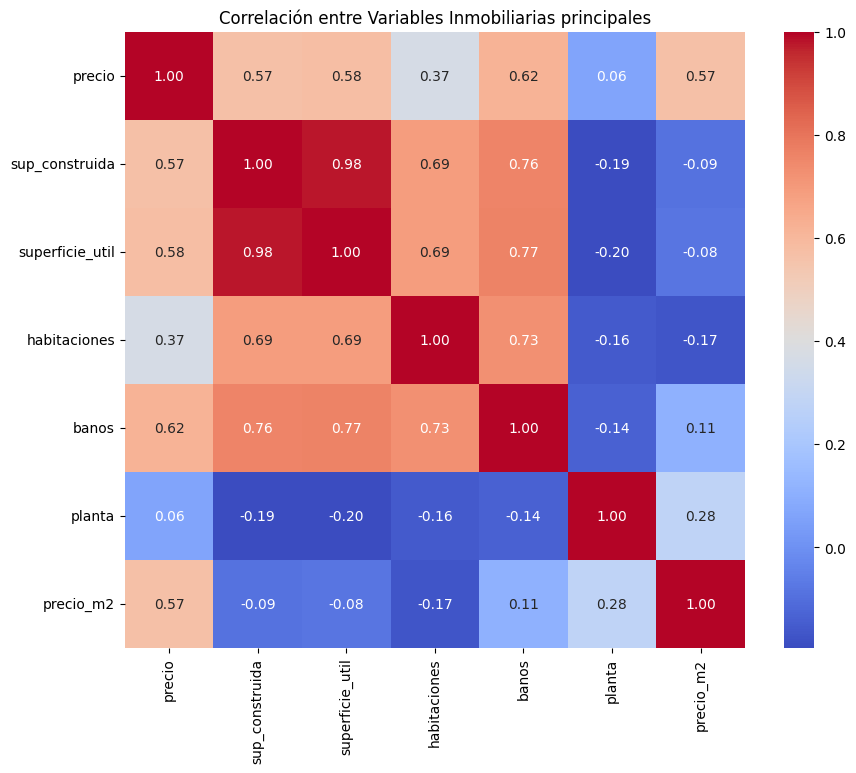

In [ ]:
def analisis_correlacion(df):
    # Seleccion de variables numéricas principales (sin los vectores v_desc)
    cols_interes = ['precio', 'sup_construida', 'superficie_util', 'habitaciones', 'banos', 'planta', 'precio_m2']
    corr = df[cols_interes].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlación entre Variables Inmobiliarias principales')
    plt.show()

analisis_correlacion(df_embedded)

In [ ]:
def visualizar_tsne_descripciones(df, n_muestras=2000):
    # Reduccion del df a unas pocas muestras
    df_sample = df.sample(n_muestras, random_state=42)
    vectores = df_sample.filter(like='v_desc_').values

    # Configuracion de t-SNE
    print("Calculando proyección t-SNE... esto puede tardar un minuto.")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    proyeccion = tsne.fit_transform(vectores)

    # Creacion del DataFrame para el gráfico
    df_tsne = pd.DataFrame(proyeccion, columns=['x', 'y'])
    df_tsne['titulo'] = df_sample['titulo'].values
    df_tsne['precio'] = df_sample['precio'].values
    df_tsne['ubicacion'] = df_sample['ubicacion'].values

    # Gráfico interactivo
    fig = px.scatter(df_tsne, x='x', y='y',
                     hover_data=['titulo', 'precio', 'ubicacion'],
                     color='precio', # Los colores indican el precio
                     title='Mapa Semántico de las Viviendas (t-SNE)',
                     color_continuous_scale='Viridis')
    fig.show()

visualizar_tsne_descripciones(df_embedded)

Calculando proyección t-SNE... esto puede tardar un minuto.


/tmp/ipykernel_31981/2753799986.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




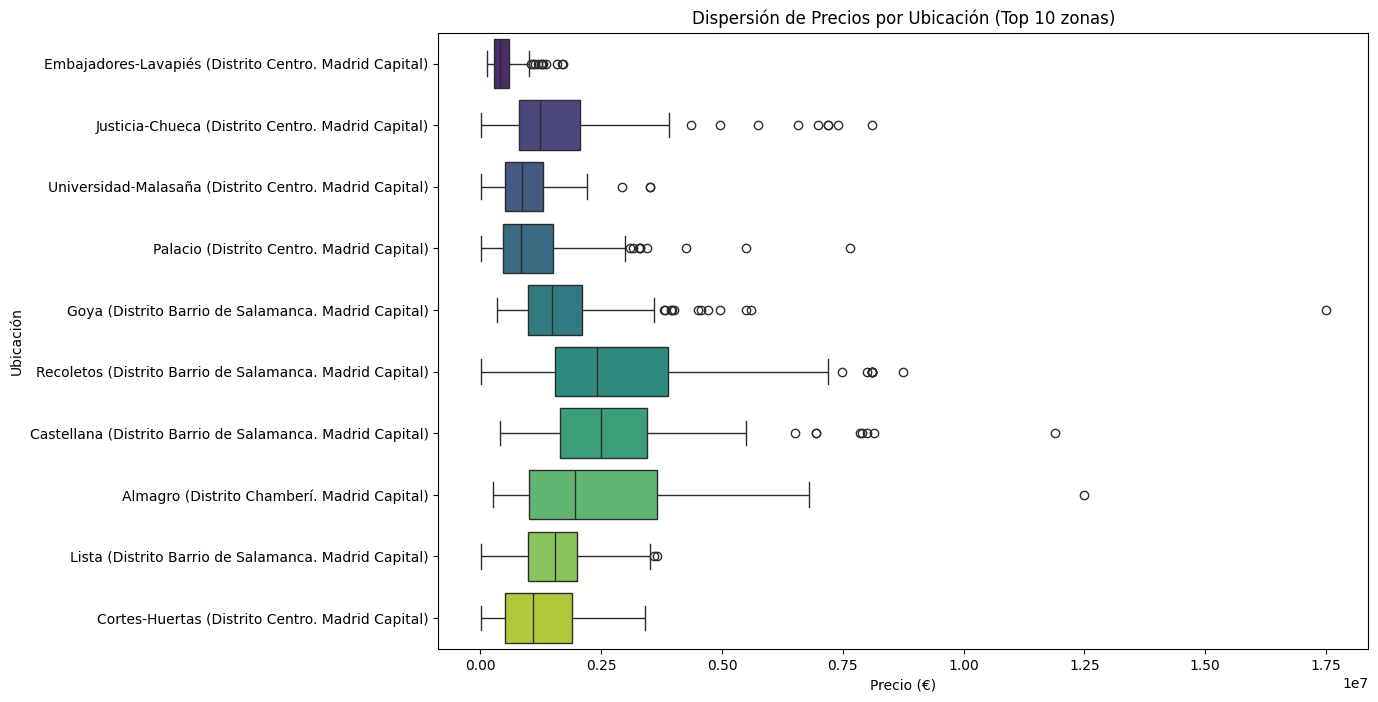

In [ ]:
def generar_boxplot(df_embedded):
  top_ubicaciones = df_embedded['ubicacion'].value_counts().nlargest(10).index
  df_top_zonas = df_embedded[df_embedded['ubicacion'].isin(top_ubicaciones)]

  plt.figure(figsize=(12, 8))
  sns.boxplot(x='precio', y='ubicacion', data=df_top_zonas, palette='viridis')
  plt.title('Dispersión de Precios por Ubicación (Top 10 zonas)')
  plt.xlabel('Precio (€)')
  plt.ylabel('Ubicación')
  plt.show()

generar_boxplot(df_embedded)

## Modelo predictivo: BART

### Modelo inicial

A partir de este punto se construye el primer modelo predictivo del trabajo mediante Bayesian Additive Regression Trees. El objetivo no es únicamente obtener una predicción puntual del precio, sino aproximar una distribución posterior para cada anuncio. Esta distribución permite cuantificar incertidumbre y, posteriormente, identificar listados cuyo precio observado se sitúa de forma anómala por debajo del valor estimado por el sistema.

El experimento principal se centra en `df_embedded`, ya que es la versión más completa: combina variables estructurales, características extraídas del anuncio y embeddings semánticos de la descripción.

Para medir el valor añadido del NLP, se entrena además un modelo de control sin embeddings.


In [ ]:
%pip install -q pymc-bart arviz pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.3 MB/s eta 0:00:00


In [ ]:
# Imports necesarios para el apartado de BART
import sys
import subprocess
import importlib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def instalar_si_falta(modulo, paquete=None):
    """Instala una dependencia dentro de Colab si todavia no esta disponible."""
    paquete = paquete or modulo
    try:
        return importlib.import_module(modulo)
    except ModuleNotFoundError:
        print(f"Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])
        importlib.invalidate_caches()
        return importlib.import_module(modulo)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

import pymc as pm
pmb = instalar_si_falta("pymc_bart", "pymc-bart")
import arviz as az

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
try:
    az.style.use("arviz-white")
except Exception:
    pass

print(f"PyMC: {pm.__version__}")
print(f"PyMC-BART: {getattr(pmb, '__version__', 'version no disponible')}")

PyMC: 5.28.4
PyMC-BART: 0.11.0


In [ ]:
# Importacion del dataset desde el drive
drive.mount('/content/drive')
ruta = '/content/drive/My Drive/pisos_madrid_FINAL_NLP.parquet'
df_embedded = pd.read_parquet(ruta)
df_embedded.head()

Mounted at /content/drive


,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,ubicacion,sistema_de_seguridad,...,v_desc_1014,v_desc_1015,v_desc_1016,v_desc_1017,v_desc_1018,v_desc_1019,v_desc_1020,v_desc_1021,v_desc_1022,v_desc_1023
0,https://www.pisos.com/comprar/chalet-cercedill...,Chalet en venta en Cerro Colgado,495000.0,331.0,1495.0,5.0,4.0,0.0,Cercedilla,0,...,-0.010327,-0.029669,0.035715,-0.025548,0.002131,0.022441,0.016234,-0.018609,-0.044136,0.014363
1,https://www.pisos.com/comprar/piso-ibiza-63333...,Piso en venta en Ibiza,1185000.0,128.0,9257.0,3.0,2.0,3.0,Ibiza (Distrito Retiro. Madrid Capital),0,...,-0.006187,-0.028535,0.035660,-0.019732,0.010020,0.018484,-0.009557,-0.004324,-0.025805,0.018386
2,https://www.pisos.com/comprar/piso-avanzada_la...,"Piso en venta en Calle de los Ángeles, 1",226000.0,77.0,2935.0,2.0,2.0,0.0,Avanzada-La Cueva (Fuenlabrada),0,...,-0.012690,-0.034037,0.045735,-0.021298,0.015506,0.041253,0.000417,-0.016744,-0.048077,0.003259
3,https://www.pisos.com/comprar/chalet-las_rozas...,Chalet en venta en Avenida de Cerro de la Curi...,1495000.0,455.0,3285.0,4.0,4.0,0.0,Centro (Las Rozas de Madrid),0,...,-0.013747,-0.031613,0.045943,-0.019789,-0.003267,0.017331,0.021861,-0.013276,-0.033984,0.014641
4,https://www.pisos.com/comprar/casa_adosada-par...,Casa adosada en venta en Parquelagos-Puente Nuevo,690000.0,407.0,1695.0,5.0,5.0,0.0,Parquelagos-Puente Nuevo (Galapagar),0,...,-0.016348,-0.037683,0.033000,-0.016178,-0.002690,0.011542,0.011905,-0.009154,-0.050135,0.015347


#### Diseño del experimento inicial

La variable objetivo es `precio`, que representa el precio de venta publicado. Antes de entrenar, se excluyen columnas identificativas o textuales que no deben entrar directamente en BART, como `url`, `titulo` y `descripcion`.

También se excluye `precio_m2` para evitar fuga de información. Esta variable se calcula a partir del propio precio y la superficie, por lo que permitir que el modelo la use como predictor equivaldría a introducir indirectamente parte de la respuesta. El entrenamiento se realiza sobre `log(1 + precio)`, lo que reduce la asimetría de la distribución de precios y suaviza el efecto de inmuebles extremadamente caros.


In [ ]:
# Variable objetivo y columnas que no deben entrar como predictores
TARGET = "precio"
EMBED_PREFIX = "v_desc_"

COLUMNAS_EXCLUIR = {
    "precio",          # variable objetivo
    "precio_m2",       # fuga de informacion: se calcula con precio / superficie
    "url",
    "titulo",
    "descripcion"
}

# Parametros del experimento
TEST_SIZE = 0.20
N_COMPONENTES_EMBEDDINGS = 50
MIN_FREQ_CATEGORIA = 20
MAX_CATEGORIAS = 700
MAX_FILAS_BART = None

# Parametros del sampler.
M_TREES = 80
DRAWS = 600
TUNE = 600
CHAINS = 2
CORES = 1
TARGET_ACCEPT = 0.90

**Preparación de las matrices de entrenamiento**

En esta fase se transforman los datos brutos en matrices numéricas aptas para BART. Las variables numéricas se imputan y estandarizan, las categóricas se codifican mediante one-hot encoding y los embeddings de descripción se reducen mediante PCA.

La reducción PCA es necesaria porque cada anuncio contiene 1024 dimensiones semánticas. Introducir todas directamente aumentaría mucho el coste computacional y podría deteriorar la estabilidad del muestreo. Por ello, se conservan componentes principales que resumen la información semántica más relevante antes de alimentar el modelo bayesiano.


In [ ]:
def _ordenar_embeddings(cols):
    """Ordena las columnas de embeddings por su indice numerico."""
    def clave(col):
        """Extrae el indice final de cada columna de embedding."""
        try:
            return int(str(col).split("_")[-1])
        except ValueError:
            return str(col)
    return sorted(cols, key=clave)


def _crear_onehot(min_frequency=20):
    """Crea un OneHotEncoder compatible con versiones nuevas y antiguas de scikit-learn."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=min_frequency,
            sparse_output=False,
        )
    except TypeError:
        try:
            return OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=min_frequency,
                sparse=False,
            )
        except TypeError:
            return OneHotEncoder(handle_unknown="ignore", sparse=False)


def _detectar_columnas(df, usar_embeddings=True):
    """Clasifica columnas numericas, categoricas y de embeddings para el preprocesado."""
    df = df.copy()
    embedding_cols = _ordenar_embeddings([c for c in df.columns if str(c).startswith(EMBED_PREFIX)])
    if not usar_embeddings:
        embedding_cols = []

    excluidas = set(COLUMNAS_EXCLUIR)
    if not usar_embeddings:
        excluidas.update([c for c in df.columns if str(c).startswith(EMBED_PREFIX)])

    numeric_cols = []
    categorical_cols = []

    for col in df.columns:
        if col in excluidas or col in embedding_cols:
            continue

        serie = df[col]
        if pd.api.types.is_numeric_dtype(serie) or pd.api.types.is_bool_dtype(serie):
            numeric_cols.append(col)
            continue

        serie_num = pd.to_numeric(serie, errors="coerce")
        proporcion_numerica = serie_num.notna().mean()
        if proporcion_numerica >= 0.90:
            df[col] = serie_num
            numeric_cols.append(col)
            continue

        n_categorias = serie.astype("string").nunique(dropna=True)
        if 1 < n_categorias <= MAX_CATEGORIAS:
            categorical_cols.append(col)

    return df, numeric_cols, categorical_cols, embedding_cols


def _obtener_feature_names(preprocessor, numeric_cols, categorical_cols, n_pca):
    """Recupera los nombres de las variables generadas por el preprocesador."""
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        nombres = list(numeric_cols)
        if categorical_cols:
            cat_pipe = preprocessor.named_transformers_.get("cat")
            onehot = cat_pipe.named_steps.get("onehot")
            nombres.extend(list(onehot.get_feature_names_out(categorical_cols)))
        if n_pca:
            nombres.extend([f"embedding_pca_{i + 1}" for i in range(n_pca)])
        return nombres


def preparar_matrices_bart(
    df,
    usar_embeddings=True,
    test_size=TEST_SIZE,
    n_componentes_embeddings=N_COMPONENTES_EMBEDDINGS,
    max_filas=MAX_FILAS_BART,
    random_state=RANDOM_SEED,
):
    """Limpia, parte train/test y transforma el dataset para PyMC-BART."""
    df_model = df.copy()
    df_model.columns = [str(c) for c in df_model.columns]

    y = pd.to_numeric(df_model[TARGET], errors="coerce")
    mask = y.notna() & np.isfinite(y) & (y > 0)
    df_model = df_model.loc[mask].reset_index(drop=True)
    y = y.loc[mask].astype(float).reset_index(drop=True)

    if max_filas is not None and len(df_model) > max_filas:
        muestra = df_model.sample(n=max_filas, random_state=random_state).index
        df_model = df_model.loc[muestra].reset_index(drop=True)
        y = y.loc[muestra].reset_index(drop=True)

    df_model, numeric_cols, categorical_cols, embedding_cols = _detectar_columnas(
        df_model,
        usar_embeddings=usar_embeddings,
    )

    indices = np.arange(len(df_model))
    try:
        stratify = pd.qcut(np.log1p(y), q=10, duplicates="drop")
        if stratify.nunique() < 2:
            stratify = None
    except ValueError:
        stratify = None

    idx_train, idx_test = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify,
    )

    df_train = df_model.iloc[idx_train].copy()
    df_test = df_model.iloc[idx_test].copy()
    y_train = y.iloc[idx_train].to_numpy(dtype=float)
    y_test = y.iloc[idx_test].to_numpy(dtype=float)

    transformers = []
    if numeric_cols:
        transformers.append((
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_cols,
        ))

    if categorical_cols:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", _crear_onehot(MIN_FREQ_CATEGORIA)),
            ]),
            categorical_cols,
        ))

    n_pca = 0
    if embedding_cols:
        n_pca = min(n_componentes_embeddings, len(embedding_cols), max(1, len(df_train) - 1))
        transformers.append((
            "emb",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=n_pca, random_state=random_state)),
            ]),
            embedding_cols,
        ))

    if not transformers:
        raise ValueError("No se han encontrado columnas predictoras validas para entrenar BART.")

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    X_train = preprocessor.fit_transform(df_train)
    X_test = preprocessor.transform(df_test)

    X_train = np.asarray(X_train, dtype="float64")
    X_test = np.asarray(X_test, dtype="float64")
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    feature_names = _obtener_feature_names(preprocessor, numeric_cols, categorical_cols, n_pca)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_train_log": y_train_log,
        "y_test_log": y_test_log,
        "df_train_meta": df_train.reset_index(drop=True),
        "df_test_meta": df_test.reset_index(drop=True),
        "preprocessor": preprocessor,
        "feature_names": feature_names,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "embedding_cols": embedding_cols,
        "n_pca": n_pca,
    }


def resumen_matrices(matrices):
    print("Filas train/test:", matrices["X_train"].shape[0], "/", matrices["X_test"].shape[0])
    print("Variables finales:", matrices["X_train"].shape[1])
    print("Numericas:", len(matrices["numeric_cols"]))
    print("Categoricas:", len(matrices["categorical_cols"]))
    print("Embeddings originales:", len(matrices["embedding_cols"]))
    print("Componentes PCA embeddings:", matrices["n_pca"])


matrices_bart = preparar_matrices_bart(df_embedded, usar_embeddings=True)
resumen_matrices(matrices_bart)

Filas train/test: 8032 / 2009
Variables finales: 213
Numericas: 40
Categoricas: 1
Embeddings originales: 1024
Componentes PCA embeddings: 50


**Funciones de entrenamiento, evaluación y detección preliminar**

Las funciones siguientes encapsulan el entrenamiento y la evaluación del modelo. El flujo es siempre el mismo: se divide el dataset en entrenamiento y test, se ajusta BART sobre la escala logarítmica del precio, se generan predicciones posteriores para el conjunto de test y se devuelven los resultados a euros.

Además de las métricas tradicionales de regresión, se construye una primera tabla de posibles oportunidades. Esta tabla compara el precio real con la distribución posterior del precio predicho y ordena los anuncios donde el modelo estima un valor sustancialmente superior al publicado.

In [ ]:
def _samples_a_matriz(xarray_values):
    """Convierte cadenas/draws de ArviZ a matriz [muestras_posteriores, observaciones]."""
    arr = np.asarray(xarray_values)
    return arr.reshape(-1, arr.shape[-1])


def resumir_posterior_precios(samples_log):
    """Transforma predicciones logaritmicas a euros y calcula percentiles posteriores."""
    samples_precio = np.expm1(samples_log)
    return {
        "samples_precio": samples_precio,
        "media": samples_precio.mean(axis=0),
        "p05": np.percentile(samples_precio, 5, axis=0),
        "p50": np.percentile(samples_precio, 50, axis=0),
        "p95": np.percentile(samples_precio, 95, axis=0),
    }


def metricas_regresion(y_real, y_pred):
    """Calcula las metricas principales de error predictivo."""
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / np.maximum(y_real, 1))) * 100
    return pd.Series({"RMSE": rmse, "MAE": mae, "R2": r2, "MAPE_%": mape})


def construir_tabla_anomalias(df_test_meta, y_test, resumen_pred, prob_umbral=0.95, descuento_min=0.15):
    """Construye el ranking preliminar de anuncios potencialmente infravalorados."""
    samples_precio = resumen_pred["samples_precio"]
    pred_p50 = resumen_pred["p50"]
    pred_p05 = resumen_pred["p05"]
    pred_p95 = resumen_pred["p95"]

    resultado = df_test_meta.copy()
    resultado["precio_real"] = y_test
    resultado["precio_predicho_p05"] = pred_p05
    resultado["precio_predicho_mediana"] = pred_p50
    resultado["precio_predicho_p95"] = pred_p95
    resultado["diferencia_pred_real"] = pred_p50 - y_test
    resultado["descuento_estimado_pct"] = resultado["diferencia_pred_real"] / np.maximum(pred_p50, 1)
    resultado["prob_pred_mayor_real"] = (samples_precio > y_test[None, :]).mean(axis=0)

    resultado["anomalia_infravalorada"] = (
        (resultado["prob_pred_mayor_real"] >= prob_umbral)
        & (resultado["descuento_estimado_pct"] >= descuento_min)
        & (resultado["precio_real"] < resultado["precio_predicho_p05"])
    )

    columnas_front = [
        "url",
        "titulo",
        "ubicacion",
        "precio_real",
        "precio_predicho_p05",
        "precio_predicho_mediana",
        "precio_predicho_p95",
        "diferencia_pred_real",
        "descuento_estimado_pct",
        "prob_pred_mayor_real",
        "anomalia_infravalorada",
    ]
    columnas_front = [c for c in columnas_front if c in resultado.columns]

    return resultado[columnas_front + [c for c in resultado.columns if c not in columnas_front]].sort_values(
        ["anomalia_infravalorada", "prob_pred_mayor_real", "descuento_estimado_pct"],
        ascending=[False, False, False],
    )


def entrenar_y_evaluar_bart(
    df,
    nombre_modelo="BART_embeddings",
    usar_embeddings=True,
    m_trees=M_TREES,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    cores=CORES,
    target_accept=TARGET_ACCEPT,
    max_filas=MAX_FILAS_BART,
):
    """Entrena BART, genera predicciones posteriores y devuelve metricas y anomalias."""
    matrices = preparar_matrices_bart(
        df,
        usar_embeddings=usar_embeddings,
        max_filas=max_filas,
    )
    resumen_matrices(matrices)

    X_train = matrices["X_train"]
    X_test = matrices["X_test"]
    y_train_log = matrices["y_train_log"]
    y_test = matrices["y_test"]

    with pm.Model() as modelo_bart:
        X_shared = pm.Data("X", X_train)
        mu = pmb.BART("mu", X_shared, y_train_log, m=m_trees)
        sigma = pm.HalfNormal("sigma", sigma=np.std(y_train_log))
        pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_log, shape=mu.shape)

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            random_seed=RANDOM_SEED,
            compute_convergence_checks=True,
        )

        posterior_train = pm.sample_posterior_predictive(
            idata,
            var_names=["mu", "y_obs"],
            random_seed=RANDOM_SEED,
        )

        X_shared.set_value(X_test)
        posterior_test = pm.sample_posterior_predictive(
            idata,
            var_names=["mu", "y_obs"],
            predictions=True,
            random_seed=RANDOM_SEED,
        )

    mu_test_log = _samples_a_matriz(posterior_test.predictions["mu"].values)
    resumen_test = resumir_posterior_precios(mu_test_log)
    pred_test = resumen_test["p50"]

    metricas = metricas_regresion(y_test, pred_test).to_frame(nombre_modelo).T
    anomalias = construir_tabla_anomalias(
        matrices["df_test_meta"],
        y_test,
        resumen_test,
    )

    return {
        "nombre_modelo": nombre_modelo,
        "modelo": modelo_bart,
        "idata": idata,
        "posterior_train": posterior_train,
        "posterior_test": posterior_test,
        "matrices": matrices,
        "resumen_test": resumen_test,
        "metricas": metricas,
        "anomalias": anomalias,
    }

#### Entrenamiento del modelo semántico

El primer modelo completo se entrena sobre `df_embedded`, incorporando tanto variables estructurales como componentes semánticos procedentes de los embeddings. Esta versión representa la hipótesis central del trabajo: las descripciones de los anuncios contienen información económica útil que no aparece completamente reflejada en las variables tabulares.

Las métricas obtenidas en test permiten valorar la capacidad predictiva del sistema sobre anuncios no vistos durante el entrenamiento.

In [ ]:
resultado_bart_embedded = entrenar_y_evaluar_bart(
    df_embedded,
    nombre_modelo="BART_estructural_semantico",
    usar_embeddings=True,
)

resultado_bart_embedded["metricas"]

Filas train/test: 8032 / 2009
Variables finales: 213
Numericas: 40
Categoricas: 1
Embeddings originales: 1024
Componentes PCA embeddings: 50


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

,RMSE,MAE,R2,MAPE_%
BART_estructural_semantico,740206.425095,287288.524778,0.569963,98.512875


**Diagnóstico de la inferencia bayesiana**

Tras el entrenamiento se revisa el comportamiento de la inferencia posterior. En particular, el parámetro `sigma` resume la dispersión residual del modelo en escala logarítmica. También es importante observar advertencias sobre `r_hat` o tamaño efectivo de muestra, ya que BART se estima mediante MCMC y la calidad de las cadenas condiciona la fiabilidad de la incertidumbre posterior.


In [ ]:
# Diagnostico Bayesiano basico
az.summary(resultado_bart_embedded["idata"], var_names=["sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.546,0.007,0.534,0.559,0.0,0.0,206.0,436.0,1.02


**Detección preliminar de oportunidades**

Una vez obtenidas las predicciones posteriores, se genera un primer ranking de anuncios potencialmente infravalorados.


In [ ]:
# Top de posibles oportunidades: precio real claramente por debajo del precio posterior esperado
anomalias_bart = resultado_bart_embedded["anomalias"]
anomalias_bart.head(5)

,url,titulo,ubicacion,precio_real,precio_predicho_p05,precio_predicho_mediana,precio_predicho_p95,diferencia_pred_real,descuento_estimado_pct,prob_pred_mayor_real,...,v_desc_1014,v_desc_1015,v_desc_1016,v_desc_1017,v_desc_1018,v_desc_1019,v_desc_1020,v_desc_1021,v_desc_1022,v_desc_1023
595,https://www.pisos.com/comprar/piso-norte_unive...,"Piso en venta en Calle de Alonso Cano, 2",Norte-Universidad (Móstoles),450.0,245998.611223,337424.077108,4.508885e+05,336974.077108,0.998666,1.0,...,-0.010978,-0.026897,0.034151,-0.009229,-0.000222,0.027723,0.014099,-0.026428,-0.052347,0.010727
276,https://www.pisos.com/comprar/piso-universidad...,"Piso en venta en Calle de Antonio Grilo, 6",Universidad-Malasaña (Distrito Centro. Madrid ...,1800.0,401855.556250,528056.787997,7.082639e+05,526256.787997,0.996591,1.0,...,-0.015335,-0.022864,0.014906,-0.023700,0.010689,-0.006729,0.015869,-0.002204,-0.046284,-0.000673
197,https://www.pisos.com/comprar/piso-valderas_lo...,"Piso en venta en Calle del Parque del Teide, 33",Valderas-Los Castillos-Parque Lisboa (Alcorcón),1200.0,192871.169785,256649.014178,3.452099e+05,255449.014178,0.995324,1.0,...,-0.007668,-0.056221,0.040654,-0.007515,0.012973,0.005853,-0.010565,-0.024670,-0.037281,-0.002738
383,https://www.pisos.com/comprar/finca_rustica-lo...,Finca rústica en venta en Calle de los Peñotes...,Lozoyuela (Lozoyuela-Navas-Sieteiglesias),20000.0,203726.979017,266207.249039,3.429656e+05,246207.249039,0.924871,1.0,...,-0.013552,-0.046930,0.039044,-0.013667,0.005283,0.036801,0.026835,-0.016110,-0.029856,0.013279
31,https://www.pisos.com/comprar/chalet-valdemaqu...,"Chalet en venta en Avenida de las Chorreras, 2",Valdemaqueda,95000.0,568507.732354,759712.776073,1.009224e+06,664712.776073,0.874953,1.0,...,-0.005802,-0.021788,0.016500,-0.005600,-0.004265,0.013480,0.012299,-0.000731,-0.039153,0.009094


#### Modelo de control sin embeddings

Para aislar el valor añadido de las variables semánticas, se entrena un segundo modelo usando las mismas variables estructurales pero eliminando los embeddings `v_desc_*`. La comparación entre ambos modelos permite evaluar si el procesamiento de lenguaje natural mejora realmente la predicción o si la mayor parte de la señal ya estaba capturada por las variables tradicionales del inmueble.

In [ ]:
# Modelo de control: mismas filas/estructura general, pero sin v_desc_*
resultado_bart_estructural = entrenar_y_evaluar_bart(
    df_embedded,
    nombre_modelo="BART_solo_estructural",
    usar_embeddings=False,
)

comparativa_bart = pd.concat([
    resultado_bart_estructural["metricas"],
    resultado_bart_embedded["metricas"],
])
comparativa_bart

Filas train/test: 8032 / 2009
Variables finales: 163
Numericas: 40
Categoricas: 1
Embeddings originales: 0
Componentes PCA embeddings: 0


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

,RMSE,MAE,R2,MAPE_%
BART_solo_estructural,783904.699671,338657.402650,0.517689,100.181643
BART_estructural_semantico,740206.425095,287288.524778,0.569963,98.512875


In [ ]:
# Guardado de la evidencia de mejora aportada por los embeddings
ruta_evidencia_embeddings = "/content/drive/My Drive/evidencia_embeddings_bart.csv"

comparativa_bart.to_csv(ruta_evidencia_embeddings, index=True, encoding="utf-8-sig")

print("Comparativa BART con/sin embeddings guardada en:", ruta_evidencia_embeddings)

Comparativa BART con/sin embeddings guardada en: /content/drive/My Drive/evidencia_embeddings_bart.csv


### Mejora del modelo: depuracion del dataset y reentrenamiento

Los primeros resultados muestran que BART identifica como oportunidades algunos anuncios con precios incompatibles con compraventa residencial, por ejemplo precios de cientos o pocos miles de euros. Antes de volver a entrenar, se crea una version depurada del dataset para eliminar errores de scraping, anuncios mal clasificados y activos no comparables con vivienda urbana estandar.

Esta fase no debe interpretarse como una manipulacion del resultado, sino como una auditoria de calidad del dato. En modelos inmobiliarios, las observaciones extremas pueden corresponder a garajes, suelos, alquileres mal capturados, precios incompletos o inmuebles no comparables. Si permanecen en el entrenamiento, el modelo aprende una mezcla de mercados distintos y la deteccion posterior de anomalías confunde oportunidades reales con errores de origen.

In [ ]:
# Configuracion de limpieza para el modelo final
# Estos umbrales son deliberadamente conservadores y se pueden justificar como filtros de compraventa residencial comparable en la Comunidad de Madrid.
MIN_PRECIO_COMPRA = 50_000
MAX_PRECIO_COMPRA = 5_000_000
MIN_PRECIO_M2 = 700
MAX_PRECIO_M2 = 25_000
MIN_SUPERFICIE = 20
MAX_SUPERFICIE = 1_000
MAX_HABITACIONES = 12
MAX_BANOS = 10

# Tipologias que conviene modelar por separado porque no compiten en el mismo mercado que pisos/chalets/casas residenciales estandar.
PATRON_TIPOLOGIAS_NO_COMPARABLES = (
    r"finca\s+rustica|terreno|solar|parcela|suelo\s+urbano|"
    r"garaje|trastero|local\s+comercial|nave|oficina"
)


def preparar_columnas_auditoria(df):
    """Normaliza columnas clave para auditar precios, superficies y tipologias."""
    df_audit = df.copy()
    for col in ["precio", "precio_m2", "sup_construida", "habitaciones", "banos", "baños"]:
        if col in df_audit.columns:
            df_audit[col] = pd.to_numeric(df_audit[col], errors="coerce")

    if "banos" not in df_audit.columns and "baños" in df_audit.columns:
        df_audit["banos"] = df_audit["baños"]

    texto_cols = [c for c in ["titulo", "url", "ubicacion"] if c in df_audit.columns]
    if texto_cols:
        df_audit["texto_auditoria"] = (
            df_audit[texto_cols]
            .fillna("")
            .astype(str)
            .agg(" ".join, axis=1)
            .str.lower()
            .str.normalize("NFKD")
            .str.encode("ascii", errors="ignore")
            .str.decode("utf-8")
        )
    else:
        df_audit["texto_auditoria"] = ""

    return df_audit


def construir_motivos_descarte(df):
    """Marca los registros que incumplen los filtros de calidad definidos."""
    motivos = pd.DataFrame(index=df.index)
    motivos["precio_fuera_rango"] = df["precio"].isna() | (df["precio"] < MIN_PRECIO_COMPRA) | (df["precio"] > MAX_PRECIO_COMPRA)

    if "precio_m2" in df.columns:
        motivos["precio_m2_fuera_rango"] = df["precio_m2"].isna() | (df["precio_m2"] < MIN_PRECIO_M2) | (df["precio_m2"] > MAX_PRECIO_M2)
    else:
        motivos["precio_m2_fuera_rango"] = False

    if "sup_construida" in df.columns:
        motivos["superficie_fuera_rango"] = df["sup_construida"].isna() | (df["sup_construida"] < MIN_SUPERFICIE) | (df["sup_construida"] > MAX_SUPERFICIE)
    else:
        motivos["superficie_fuera_rango"] = False

    if "habitaciones" in df.columns:
        motivos["habitaciones_fuera_rango"] = df["habitaciones"].isna() | (df["habitaciones"] < 0) | (df["habitaciones"] > MAX_HABITACIONES)
    else:
        motivos["habitaciones_fuera_rango"] = False

    if "banos" in df.columns:
        motivos["banos_fuera_rango"] = df["banos"].isna() | (df["banos"] < 0) | (df["banos"] > MAX_BANOS)
    else:
        motivos["banos_fuera_rango"] = False

    motivos["tipologia_no_comparable"] = df["texto_auditoria"].str.contains(
        PATRON_TIPOLOGIAS_NO_COMPARABLES,
        regex=True,
        na=False,
    )
    return motivos


def filtrar_dataset_para_bart(df):
    """Aplica los filtros de calidad y devuelve dataset limpio, descartes y resumen."""
    df_audit = preparar_columnas_auditoria(df)
    motivos = construir_motivos_descarte(df_audit)
    mask_descartar = motivos.any(axis=1)

    df_limpio = df.loc[~mask_descartar].copy().reset_index(drop=True)
    df_descartado = df.loc[mask_descartar].copy()
    motivos_descartados = motivos.loc[mask_descartar].copy()
    df_descartado["motivos_descarte"] = motivos_descartados.apply(
        lambda fila: ", ".join(fila.index[fila.values]),
        axis=1,
    )

    resumen = (
        motivos.sum()
        .sort_values(ascending=False)
        .rename("n_descartes")
        .to_frame()
    )
    resumen["pct_dataset"] = resumen["n_descartes"] / len(df) * 100

    return df_limpio, df_descartado.reset_index(drop=True), resumen


df_bart_filtrado, df_bart_descartado, resumen_filtros_bart = filtrar_dataset_para_bart(df_embedded)

print(f"Registros originales: {len(df_embedded):,}")
print(f"Registros filtrados:  {len(df_bart_filtrado):,}")
print(f"Registros descartados: {len(df_bart_descartado):,}")
resumen_filtros_bart

Registros originales: 10,041
Registros filtrados:  9,632
Registros descartados: 409


,n_descartes,pct_dataset
precio_m2_fuera_rango,222,2.210935
precio_fuera_rango,165,1.643263
tipologia_no_comparable,72,0.717060
superficie_fuera_rango,57,0.567673
banos_fuera_rango,16,0.159347
habitaciones_fuera_rango,10,0.099592


In [ ]:
# Parametros del modelo depurado
M_TREES_FILTRADO = 120
DRAWS_FILTRADO = 800
TUNE_FILTRADO = 800

resultado_bart_filtrado = entrenar_y_evaluar_bart(
    df_bart_filtrado,
    nombre_modelo="BART_semantico_filtrado",
    usar_embeddings=True,
    m_trees=M_TREES_FILTRADO,
    draws=DRAWS_FILTRADO,
    tune=TUNE_FILTRADO,
    chains=CHAINS,
    cores=CORES,
    target_accept=TARGET_ACCEPT,
)

resultado_bart_filtrado["metricas"]

Filas train/test: 7705 / 1927
Variables finales: 209
Numericas: 40
Categoricas: 1
Embeddings originales: 1024
Componentes PCA embeddings: 50


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

,RMSE,MAE,R2,MAPE_%
BART_semantico_filtrado,432428.764924,228328.838877,0.708075,31.01738


In [ ]:
# Diagnostico posterior del modelo filtrado
az.summary(resultado_bart_filtrado["idata"], var_names=["sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.401,0.006,0.391,0.413,0.0,0.0,207.0,553.0,1.03


In [ ]:
# Nueva tabla de candidatos tras limpiar el universo de entrenamiento/test
anomalias_bart_filtrado = resultado_bart_filtrado["anomalias"]
anomalias_bart_filtrado.head(10)

,url,titulo,ubicacion,precio_real,precio_predicho_p05,precio_predicho_mediana,precio_predicho_p95,diferencia_pred_real,descuento_estimado_pct,prob_pred_mayor_real,...,v_desc_1014,v_desc_1015,v_desc_1016,v_desc_1017,v_desc_1018,v_desc_1019,v_desc_1020,v_desc_1021,v_desc_1022,v_desc_1023
859,https://www.pisos.com/comprar/casa-puentes_vie...,Casa en venta en Calle de la Estrella,Puentes Viejas,65000.0,2.311985e+05,2.774974e+05,3.384967e+05,212497.372046,0.765764,1.0,...,-0.005909,-0.021004,0.058826,-0.002944,-0.000987,0.028569,0.009499,-0.007535,-0.034464,-0.006563
1851,https://www.pisos.com/comprar/piso-braojos-558...,Piso en venta en Braojos,Braojos,121000.0,4.189203e+05,5.122163e+05,6.284096e+05,391216.275573,0.763772,1.0,...,-0.006806,-0.071486,0.022159,-0.009867,0.013244,0.030020,0.006152,-0.014453,-0.040708,0.004150
1647,https://www.pisos.com/comprar/casa_adosada-per...,Casa adosada en venta en Avenida Alva Myrdal,Perales del Río (Getafe),250000.0,7.022705e+05,8.827823e+05,1.123555e+06,632782.276962,0.716804,1.0,...,-0.031285,-0.033779,0.015499,-0.023258,0.008728,0.007118,0.008540,-0.010402,-0.048167,0.010350
1562,https://www.pisos.com/comprar/piso-arganda_del...,Piso en venta en Calle de Zamora,Centro (Arganda del Rey),53400.0,1.489716e+05,1.810871e+05,2.163212e+05,127687.146032,0.705114,1.0,...,0.010574,-0.028513,0.021573,0.000051,0.004889,0.025745,0.029516,-0.013372,-0.024264,-0.008926
574,https://www.pisos.com/comprar/piso-puente_de_v...,Piso en venta en Calle de Peironcely,Entrevías (Distrito Puente de Vallecas. Madrid...,50000.0,1.344831e+05,1.643776e+05,2.008920e+05,114377.590724,0.695822,1.0,...,-0.000022,-0.026746,0.029946,-0.002737,0.011214,0.010994,0.013803,-0.021847,-0.041893,-0.016749
1361,https://www.pisos.com/comprar/casa_adosada-alg...,Casa adosada en venta en Calle de Félix María ...,Algete,495000.0,1.180148e+06,1.473746e+06,1.816733e+06,978745.566048,0.664121,1.0,...,-0.022249,-0.030387,0.034826,-0.022637,0.004931,0.008379,0.014773,-0.002147,-0.044306,0.006772
1068,https://www.pisos.com/comprar/piso-patones_cen...,Piso en venta en Patones,Patones,179700.0,4.236383e+05,5.195434e+05,6.370869e+05,339843.424301,0.654119,1.0,...,-0.013494,-0.037414,0.028455,-0.013532,-0.000139,0.023956,-0.002413,0.004774,-0.039215,0.012576
1604,https://www.pisos.com/comprar/chalet-uceda_cen...,Chalet en venta en Uceda,Uceda,250000.0,5.694430e+05,6.955664e+05,8.463576e+05,445566.413974,0.640581,1.0,...,-0.020948,-0.037723,0.011021,-0.027090,0.012525,0.020103,0.022846,0.006740,-0.057266,0.026709
159,https://www.pisos.com/comprar/piso-brezo_guard...,Piso en venta en Brezo-Guardia Civil,Brezo-Guardia Civil (Valdemoro),83000.0,1.897266e+05,2.293693e+05,2.753476e+05,146369.263338,0.638138,1.0,...,-0.011471,-0.038001,0.034768,-0.029694,0.003331,0.039215,-0.000772,-0.016903,-0.010183,0.008433
1164,https://www.pisos.com/comprar/piso-torrejon_de...,Piso en venta en Calle de la Virgen de la Nati...,Torrejón de la Calzada,308000.0,6.778966e+05,8.486787e+05,1.091573e+06,540678.748579,0.637083,1.0,...,-0.008997,-0.036667,0.044206,-0.000307,-0.009670,0.037913,-0.001546,-0.020351,-0.048285,-0.000808


**Evaluación visual de predicciones e intervalos**

Los gráficos permiten complementar las métricas numéricas. El diagrama de precio real frente a precio predicho muestra si el modelo se aproxima razonablemente a la diagonal de predicción perfecta. El gráfico de intervalos compara, para los principales candidatos, el precio observado con el intervalo posterior estimado por BART.

Esta visualización es especialmente útil porque el objetivo final no consiste solo en predecir precios, sino en detectar casos donde el precio publicado queda por debajo de un rango de valoración razonable.


In [ ]:
def plot_predicho_vs_real(resultado, titulo="BART: precio real vs predicho"):
    """Grafica el precio real frente al precio predicho por el modelo."""
    y_real = resultado["matrices"]["y_test"]
    pred = resultado["resumen_test"]["p50"]
    p05 = resultado["resumen_test"]["p05"]
    p95 = resultado["resumen_test"]["p95"]

    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_real, y=pred, alpha=0.35, edgecolor=None)
    max_lim = np.nanpercentile(np.concatenate([y_real, pred, p95]), 99)
    plt.plot([0, max_lim], [0, max_lim], color="black", linestyle="--", linewidth=1)
    plt.xlim(0, max_lim)
    plt.ylim(0, max_lim)
    plt.xlabel("Precio real")
    plt.ylabel("Precio predicho mediano")
    plt.title(titulo)
    plt.grid(alpha=0.2)
    plt.show()


def plot_intervalos_anomalias(resultado, n=20):
    """Visualiza los intervalos posteriores de los principales candidatos infravalorados."""
    tabla = resultado["anomalias"].head(n).copy()
    tabla = tabla.sort_values("diferencia_pred_real")
    etiquetas = tabla["titulo"].fillna(tabla.get("url", pd.Series(range(len(tabla))))).astype(str).str.slice(0, 45)

    plt.figure(figsize=(10, max(5, n * 0.35)))
    plt.hlines(
        y=np.arange(len(tabla)),
        xmin=tabla["precio_predicho_p05"],
        xmax=tabla["precio_predicho_p95"],
        color="steelblue",
        alpha=0.75,
        linewidth=3,
        label="Intervalo posterior 90%",
    )
    plt.scatter(tabla["precio_predicho_mediana"], np.arange(len(tabla)), color="navy", label="Mediana posterior")
    plt.scatter(tabla["precio_real"], np.arange(len(tabla)), color="crimson", label="Precio real")
    plt.yticks(np.arange(len(tabla)), etiquetas)
    plt.xlabel("Precio")
    plt.title("Candidatos infravalorados segun BART")
    plt.legend()
    plt.grid(axis="x", alpha=0.2)
    plt.show()

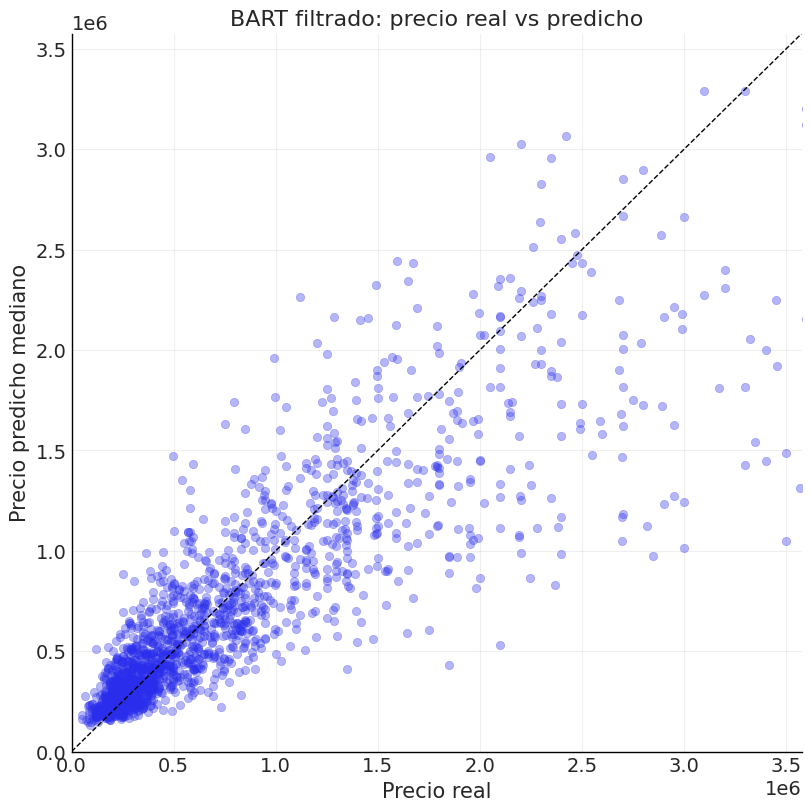

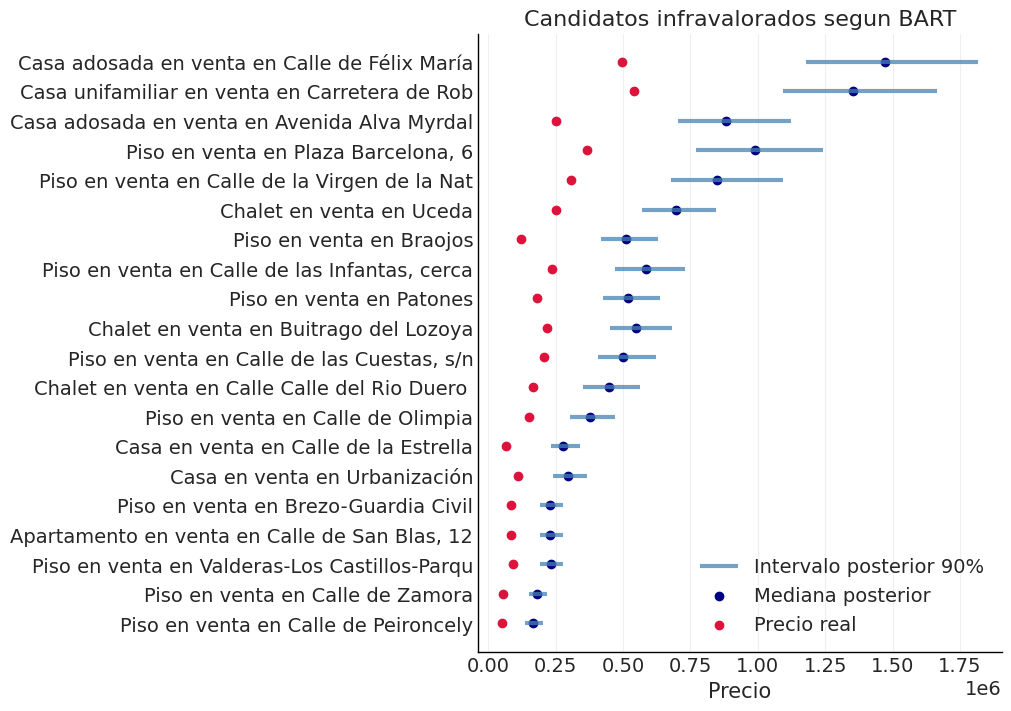

In [ ]:
plot_predicho_vs_real(resultado_bart_filtrado, titulo="BART filtrado: precio real vs predicho")
plot_intervalos_anomalias(resultado_bart_filtrado, n=20)

In [ ]:
# Comparativa final con las metricas principales
METRICAS_PRINCIPALES = ["RMSE", "MAE", "R2", "MAPE_%"]

comparativa_modelos_bart = pd.concat([
    resultado_bart_estructural["metricas"],
    resultado_bart_embedded["metricas"],
    resultado_bart_filtrado["metricas"],
])[METRICAS_PRINCIPALES]

comparativa_modelos_bart

,RMSE,MAE,R2,MAPE_%
BART_solo_estructural,783904.699671,338657.402650,0.517689,100.181643
BART_estructural_semantico,740206.425095,287288.524778,0.569963,98.512875
BART_semantico_filtrado,432428.764924,228328.838877,0.708075,31.017380


In [ ]:
def obtener_samples_predictivos_precio(resultado):
    """Devuelve muestras predictivas en euros para evaluar la cobertura posterior."""
    posterior_test = resultado.get("posterior_test")
    if posterior_test is not None and hasattr(posterior_test, "predictions"):
        if "y_obs" in posterior_test.predictions:
            samples_log = _samples_a_matriz(posterior_test.predictions["y_obs"].values)
            return np.expm1(samples_log)
        if "mu" in posterior_test.predictions:
            samples_log = _samples_a_matriz(posterior_test.predictions["mu"].values)
            return np.expm1(samples_log)

    return resultado["resumen_test"]["samples_precio"]


def diagnostico_cobertura_90(resultado):
    y_real = resultado["matrices"]["y_test"]
    samples_pred = obtener_samples_predictivos_precio(resultado)
    p05 = np.percentile(samples_pred, 5, axis=0)
    p95 = np.percentile(samples_pred, 95, axis=0)
    cobertura = ((y_real >= p05) & (y_real <= p95)).mean() * 100
    ancho_mediano = np.median(p95 - p05)
    return pd.Series({
        "Cobertura_90_%": cobertura,
        "Ancho_mediano_intervalo_90": ancho_mediano,
    })

diagnostico_cobertura_filtrado = diagnostico_cobertura_90(
    resultado_bart_filtrado
).to_frame("BART_semantico_filtrado").T

diagnostico_cobertura_filtrado

,Cobertura_90_%,Ancho_mediano_intervalo_90
BART_semantico_filtrado,92.423456,713779.404444


In [ ]:
# Guardado de resultados y datos para posterior deteccion de anomalias
ruta_comparativa_bart = "/content/drive/My Drive/comparativa_modelos_bart.csv"
ruta_predicciones_test_bart = "/content/drive/My Drive/predicciones_test_bart_filtrado.csv"
ruta_posterior_predictivo_bart = "/content/drive/My Drive/posterior_predictivo_bart_filtrado.npz"

comparativa_modelos_bart.to_csv(
    ruta_comparativa_bart,
    index=True,
    encoding="utf-8-sig"
)

# Esta tabla conserva el mismo orden que las columnas del array posterior guardado abajo.
predicciones_test_bart_filtrado = resultado_bart_filtrado["matrices"]["df_test_meta"].copy().reset_index(drop=True)
predicciones_test_bart_filtrado.insert(0, "id_test", np.arange(len(predicciones_test_bart_filtrado)))
predicciones_test_bart_filtrado["precio_real"] = resultado_bart_filtrado["matrices"]["y_test"]
predicciones_test_bart_filtrado["precio_predicho_p05"] = resultado_bart_filtrado["resumen_test"]["p05"]
predicciones_test_bart_filtrado["precio_predicho_mediana"] = resultado_bart_filtrado["resumen_test"]["p50"]
predicciones_test_bart_filtrado["precio_predicho_p95"] = resultado_bart_filtrado["resumen_test"]["p95"]

predicciones_test_bart_filtrado.to_csv(
    ruta_predicciones_test_bart,
    index=False,
    encoding="utf-8-sig"
)

samples_pred_filtrado = obtener_samples_predictivos_precio(resultado_bart_filtrado)

np.savez_compressed(
    ruta_posterior_predictivo_bart,
    samples_pred=samples_pred_filtrado,
    y_test=resultado_bart_filtrado["matrices"]["y_test"],
    pred_mediana=resultado_bart_filtrado["resumen_test"]["p50"],
    pred_p05=resultado_bart_filtrado["resumen_test"]["p05"],
    pred_p95=resultado_bart_filtrado["resumen_test"]["p95"],
)

print("Comparativa de modelos guardada en:", ruta_comparativa_bart)
print("Predicciones test guardadas en:", ruta_predicciones_test_bart)
print("Posterior predictivo guardado en:", ruta_posterior_predictivo_bart)

Comparativa de modelos guardada en: /content/drive/My Drive/comparativa_modelos_bart.csv
Predicciones test guardadas en: /content/drive/My Drive/predicciones_test_bart_filtrado.csv
Posterior predictivo guardado en: /content/drive/My Drive/posterior_predictivo_bart_filtrado.npz


## Deteccion de Anomalias y Analisis de Residuos

Una vez entrenado el modelo BART, el objetivo final es identificar anuncios cuyo precio publicado se situe de forma significativa por debajo del valor razonable estimado por el sistema. El criterio central sera bayesiano: evaluar la posicion del precio observado dentro de la distribucion posterior predictiva.

En concreto, un anuncio se considera candidato a infravaloracion cuando `P(Y_i < y_i | Datos) < 0.05`. Esta probabilidad mide lo raro que seria, bajo el modelo, que el valor razonable del inmueble fuese inferior al precio publicado. Si es muy baja, el precio observado queda en la cola izquierda de la distribucion posterior y existe evidencia estadistica de infravaloracion.

In [ ]:
# Imports necesarios para el apartado de Deteccion de Anomalias y Analisis de Residuos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
# Importacion del dataset y datos necesarios desde el drive
drive.mount('/content/drive')

ruta_predicciones_test_bart = "/content/drive/My Drive/predicciones_test_bart_filtrado.csv"
ruta_posterior_predictivo_bart = "/content/drive/My Drive/posterior_predictivo_bart_filtrado.npz"

predicciones_test_bart = pd.read_csv(ruta_predicciones_test_bart)
posterior_bart = np.load(ruta_posterior_predictivo_bart)

samples_pred_bart = posterior_bart["samples_pred"]

# Formato [muestras_posteriores, observaciones_test]
if samples_pred_bart.shape[0] == len(predicciones_test_bart) and samples_pred_bart.shape[1] != len(predicciones_test_bart):
    samples_pred_bart = samples_pred_bart.T

print("Predicciones test:", predicciones_test_bart.shape)
print("Muestras posteriores:", samples_pred_bart.shape)

assert samples_pred_bart.shape[1] == len(predicciones_test_bart), "Las predicciones y las muestras posteriores no estan alineadas."

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Predicciones test: (1927, 1074)
Muestras posteriores: (1600, 1927)


**Criterio bayesiano y filtro economico**

El criterio estadistico principal es `P(Y_i < y_i | Datos) < 0.05`. Ademas, se mantiene un filtro economico de descuento minimo. Este filtro no sustituye al criterio bayesiano, sino que evita marcar como oportunidades diferencias demasiado pequenas desde el punto de vista practico.


In [ ]:
ALPHA_ANOMALIA = 0.05
DESCUENTO_MINIMO = 0.15


def calcular_anomalias_bayesianas(predicciones, samples_pred, alpha=ALPHA_ANOMALIA, descuento_minimo=DESCUENTO_MINIMO):
    """Calcula probabilidades posteriores y marca anuncios infravalorados relevantes."""
    resultado = predicciones.copy()
    y_real = resultado["precio_real"].to_numpy(dtype=float)
    pred_mediana = resultado["precio_predicho_mediana"].to_numpy(dtype=float)

    prob_valor_menor_precio = (samples_pred < y_real[None, :]).mean(axis=0)
    prob_valor_mayor_precio = 1 - prob_valor_menor_precio

    resultado["diferencia_valor_precio"] = pred_mediana - y_real
    resultado["descuento_estimado_pct"] = resultado["diferencia_valor_precio"] / np.maximum(pred_mediana, 1)
    resultado["prob_valor_menor_precio"] = prob_valor_menor_precio
    resultado["prob_infravaloracion"] = prob_valor_mayor_precio

    resultado["anomalia_bayesiana"] = resultado["prob_valor_menor_precio"] < alpha
    resultado["anomalia_relevante"] = (
        resultado["anomalia_bayesiana"]
        & (resultado["descuento_estimado_pct"] >= descuento_minimo)
        & (resultado["diferencia_valor_precio"] > 0)
    )

    resultado["score_oportunidad"] = (
        resultado["prob_infravaloracion"]
        * resultado["descuento_estimado_pct"].clip(lower=0)
    )

    return resultado.sort_values(
        ["anomalia_relevante", "score_oportunidad", "prob_infravaloracion", "descuento_estimado_pct"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)


analisis_anomalias_bart = calcular_anomalias_bayesianas(predicciones_test_bart, samples_pred_bart)
analisis_anomalias_bart.head(5)

,id_test,url,titulo,precio,sup_construida,precio_m2,habitaciones,banos,planta,ubicacion,...,precio_predicho_p05,precio_predicho_mediana,precio_predicho_p95,diferencia_valor_precio,descuento_estimado_pct,prob_valor_menor_precio,prob_infravaloracion,anomalia_bayesiana,anomalia_relevante,score_oportunidad
0,859,https://www.pisos.com/comprar/casa-puentes_vie...,Casa en venta en Calle de la Estrella,65000.0,87.0,747.0,3.0,1.0,0.0,Puentes Viejas,...,231198.484463,277497.372046,3.384967e+05,212497.372046,0.765764,0.000000,1.000000,True,True,0.765764
1,1851,https://www.pisos.com/comprar/piso-braojos-558...,Piso en venta en Braojos,121000.0,99.0,1222.0,4.0,2.0,0.0,Braojos,...,418920.323556,512216.275573,6.284096e+05,391216.275573,0.763772,0.000000,1.000000,True,True,0.763772
2,1647,https://www.pisos.com/comprar/casa_adosada-per...,Casa adosada en venta en Avenida Alva Myrdal,250000.0,290.0,862.0,5.0,4.0,0.0,Perales del Río (Getafe),...,702270.523752,882782.276962,1.123555e+06,632782.276962,0.716804,0.000625,0.999375,True,True,0.716356
3,1562,https://www.pisos.com/comprar/piso-arganda_del...,Piso en venta en Calle de Zamora,53400.0,50.0,1068.0,1.0,1.0,0.0,Centro (Arganda del Rey),...,148971.625063,181087.146032,2.163212e+05,127687.146032,0.705114,0.000625,0.999375,True,True,0.704674
4,574,https://www.pisos.com/comprar/piso-puente_de_v...,Piso en venta en Calle de Peironcely,50000.0,37.0,1351.0,1.0,1.0,0.0,Entrevías (Distrito Puente de Vallecas. Madrid...,...,134483.091278,164377.590724,2.008920e+05,114377.590724,0.695822,0.001875,0.998125,True,True,0.694518


In [ ]:
def resumir_anomalias(tabla, alpha=ALPHA_ANOMALIA, descuento_minimo=DESCUENTO_MINIMO):
    """Resume las anomalias bayesianas y las oportunidades economicamente relevantes."""
    n_total = len(tabla)
    n_bayes = int(tabla["anomalia_bayesiana"].sum())
    n_relevantes = int(tabla["anomalia_relevante"].sum())
    return pd.DataFrame({
        "observaciones_test": [n_total],
        "anomalias_bayesianas": [n_bayes],
        "pct_anomalias_bayesianas": [n_bayes / n_total * 100],
        "anomalias_relevantes": [n_relevantes],
        "pct_anomalias_relevantes": [n_relevantes / n_total * 100],
        "alpha": [alpha],
        "descuento_minimo": [descuento_minimo],
        "descuento_mediano_relevantes": [tabla.loc[tabla["anomalia_relevante"], "descuento_estimado_pct"].median()],
    })


resumen_anomalias_bart = resumir_anomalias(analisis_anomalias_bart)
resumen_anomalias_bart

,observaciones_test,anomalias_bayesianas,pct_anomalias_bayesianas,anomalias_relevantes,pct_anomalias_relevantes,alpha,descuento_minimo,descuento_mediano_relevantes
0,1927,73,3.788272,73,3.788272,0.05,0.15,0.560965


**Ranking final de candidatos**

La siguiente tabla contiene los anuncios que cumplen el criterio bayesiano y, adicionalmente, el filtro de descuento minimo. Las columnas clave son `prob_valor_menor_precio`, que debe ser inferior a 0.05, y `descuento_estimado_pct`, que aproxima la magnitud economica de la infravaloracion estimada.


In [ ]:
columnas_ranking = [
    "id_test", "url", "titulo", "ubicacion",
    "precio_real", "precio_predicho_p05", "precio_predicho_mediana", "precio_predicho_p95",
    "diferencia_valor_precio", "descuento_estimado_pct",
    "prob_valor_menor_precio", "prob_infravaloracion", "score_oportunidad",
    "anomalia_bayesiana", "anomalia_relevante",
]
columnas_ranking = [c for c in columnas_ranking if c in analisis_anomalias_bart.columns]

ranking_anomalias_bart = analisis_anomalias_bart.loc[analisis_anomalias_bart["anomalia_relevante"], columnas_ranking]
ranking_anomalias_bart.head(5)

,id_test,url,titulo,ubicacion,precio_real,precio_predicho_p05,precio_predicho_mediana,precio_predicho_p95,diferencia_valor_precio,descuento_estimado_pct,prob_valor_menor_precio,prob_infravaloracion,score_oportunidad,anomalia_bayesiana,anomalia_relevante
0,859,https://www.pisos.com/comprar/casa-puentes_vie...,Casa en venta en Calle de la Estrella,Puentes Viejas,65000.0,231198.484463,277497.372046,3.384967e+05,212497.372046,0.765764,0.000000,1.000000,0.765764,True,True
1,1851,https://www.pisos.com/comprar/piso-braojos-558...,Piso en venta en Braojos,Braojos,121000.0,418920.323556,512216.275573,6.284096e+05,391216.275573,0.763772,0.000000,1.000000,0.763772,True,True
2,1647,https://www.pisos.com/comprar/casa_adosada-per...,Casa adosada en venta en Avenida Alva Myrdal,Perales del Río (Getafe),250000.0,702270.523752,882782.276962,1.123555e+06,632782.276962,0.716804,0.000625,0.999375,0.716356,True,True
3,1562,https://www.pisos.com/comprar/piso-arganda_del...,Piso en venta en Calle de Zamora,Centro (Arganda del Rey),53400.0,148971.625063,181087.146032,2.163212e+05,127687.146032,0.705114,0.000625,0.999375,0.704674,True,True
4,574,https://www.pisos.com/comprar/piso-puente_de_v...,Piso en venta en Calle de Peironcely,Entrevías (Distrito Puente de Vallecas. Madrid...,50000.0,134483.091278,164377.590724,2.008920e+05,114377.590724,0.695822,0.001875,0.998125,0.694518,True,True


**Visualizacion de probabilidades e intervalos**

Para interpretar el resultado, se visualiza la distribucion de la probabilidad posterior de infravaloracion y los intervalos predictivos de los principales candidatos. El precio real deberia aparecer por debajo de la zona central de la distribucion posterior en los casos mas interesantes.


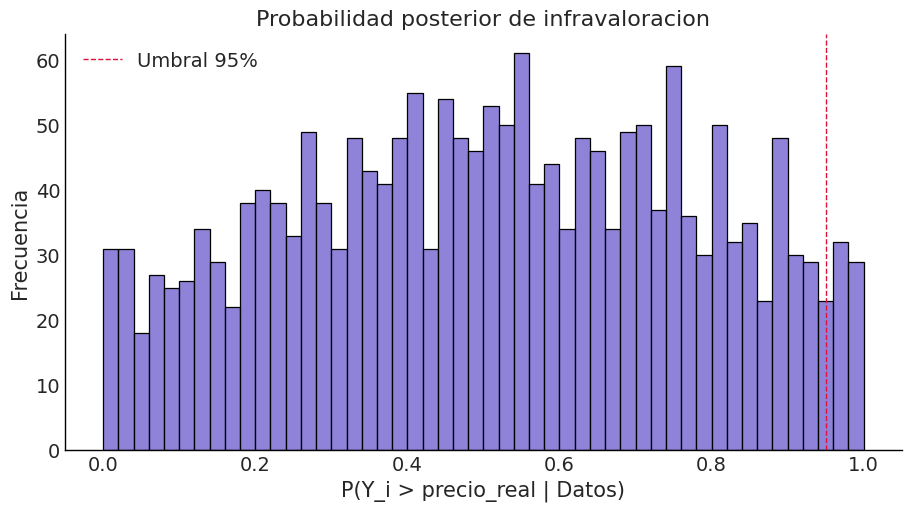

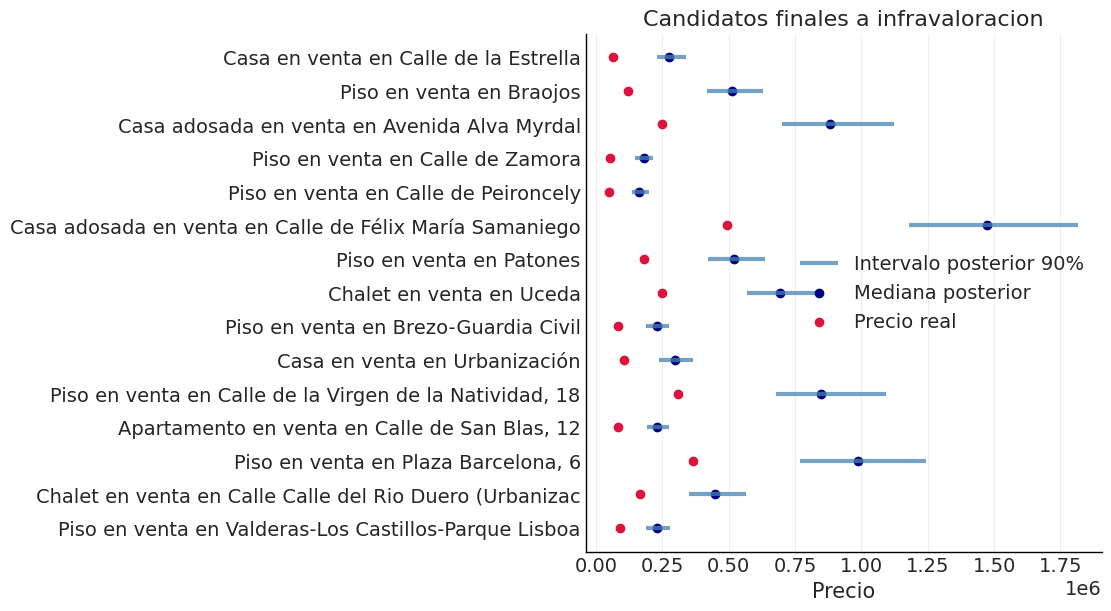

In [ ]:
def plot_probabilidades_anomalia(tabla):
    """Visualiza la distribucion de probabilidad posterior de infravaloracion."""
    plt.figure(figsize=(9, 5))
    sns.histplot(tabla["prob_infravaloracion"], bins=50, color="slateblue")
    plt.axvline(1 - ALPHA_ANOMALIA, color="crimson", linestyle="--", linewidth=1, label="Umbral 95%")
    plt.title("Probabilidad posterior de infravaloracion")
    plt.xlabel("P(Y_i > precio_real | Datos)")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()


def plot_intervalos_ranking(tabla, n=15):
    """Compara precio real e intervalo posterior para el ranking final."""
    top = tabla.loc[tabla["anomalia_relevante"]].head(n).copy()
    if top.empty:
        print("No hay anomalias que cumplan los umbrales seleccionados.")
        return

    top = top.sort_values("score_oportunidad")
    etiquetas = top["titulo"].fillna(top.get("url", pd.Series(range(len(top))))).astype(str).str.slice(0, 55)

    plt.figure(figsize=(11, max(5, n * 0.4)))
    y_pos = np.arange(len(top))
    plt.hlines(
        y=y_pos,
        xmin=top["precio_predicho_p05"],
        xmax=top["precio_predicho_p95"],
        color="steelblue",
        linewidth=3,
        alpha=0.75,
        label="Intervalo posterior 90%",
    )
    plt.scatter(top["precio_predicho_mediana"], y_pos, color="navy", label="Mediana posterior")
    plt.scatter(top["precio_real"], y_pos, color="crimson", label="Precio real")
    plt.yticks(y_pos, etiquetas)
    plt.xlabel("Precio")
    plt.title("Candidatos finales a infravaloracion")
    plt.legend()
    plt.grid(axis="x", alpha=0.2)
    plt.show()


plot_probabilidades_anomalia(analisis_anomalias_bart)
plot_intervalos_ranking(analisis_anomalias_bart, n=15)

In [ ]:
ruta_analisis_anomalias_bart = "/content/drive/My Drive/analisis_anomalias_bart_filtrado.csv"
ruta_ranking_anomalias_bart = "/content/drive/My Drive/ranking_anomalias_bart_filtrado.csv"
ruta_resumen_anomalias_bart = "/content/drive/My Drive/resumen_anomalias_bart_filtrado.csv"

analisis_anomalias_bart.to_csv(ruta_analisis_anomalias_bart, index=False, encoding="utf-8-sig")
ranking_anomalias_bart.to_csv(ruta_ranking_anomalias_bart, index=False, encoding="utf-8-sig")
resumen_anomalias_bart.to_csv(ruta_resumen_anomalias_bart, index=False, encoding="utf-8-sig")

print("Analisis de anomalias guardado en:", ruta_analisis_anomalias_bart)
print("Ranking de anomalias guardado en:", ruta_ranking_anomalias_bart)
print("Resumen de anomalias guardado en:", ruta_resumen_anomalias_bart)

Analisis de anomalias guardado en: /content/drive/My Drive/analisis_anomalias_bart_filtrado.csv
Ranking de anomalias guardado en: /content/drive/My Drive/ranking_anomalias_bart_filtrado.csv
Resumen de anomalias guardado en: /content/drive/My Drive/resumen_anomalias_bart_filtrado.csv
